# Retail Product Demand Forecasting using Time Series Analysis and Machine Learning

To forecast future product demand using historical e-commerce transaction data, enabling retailers
to optimize inventory levels, reduce stockouts and overstocking, improve supply chain planning,
and make data-driven business decisions.

Business Problem

Retail companies face several challenges:

* They don't know how many units of each product customers will buy next week or next month.
* Underestimating demand causes stockouts, leading to lost sales and dissatisfied customers.
* Overestimating demand causes excess inventory, increasing storage costs and tying up capital.
* Demand fluctuates because of seasonality, promotions, holidays, and changing customer preferences.

The objective is to build a forecasting system that predicts future demand so inventory decisions can be made proactively.

In [ ]:
Business Objectives

* Forecast future product demand accurately.
* Optimize inventory levels.
* Reduce stockouts.
* Minimize overstocking.
* Improve warehouse utilization.
* Support procurement and replenishment planning.
* Help marketing identify seasonal demand patterns.
* Improve overall supply chain efficiency.

The objective of this project is to predict future product demand using historical e-commerce transaction data from
the Olist dataset. By analyzing order history, product information, and purchasing patterns, the forecasting model
helps retailers estimate future demand, optimize inventory, reduce stockouts and excess inventory, and improve supply
chain planning. To achieve this, I built an end-to-end forecasting pipeline involving data integration,
feature engineering, exploratory analysis, time-series modeling, machine learning model comparison, and deployment.

# PHASE 1 Project Setup & Environment

In [151]:
import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Date & Time


from datetime import datetime

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

# Plot Settings
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12, 6)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [152]:
print("Pandas :", pd.__version__)
print("NumPy  :", np.__version__)
print("Matplotlib :", plt.matplotlib.__version__)
print("Seaborn :", sns.__version__)

Pandas : 2.3.3
NumPy  : 2.3.5
Matplotlib : 3.10.6
Seaborn : 0.13.2


In [153]:
# Orders Dataset
orders = pd.read_csv(r"C:\Users\amolm\Desktop\DATASETS\RETAIL_DATASET\olist_orders_dataset.csv")

# Order Items Dataset
order_items = pd.read_csv(r"C:\Users\amolm\Desktop\DATASETS\RETAIL_DATASET\olist_order_items_dataset.csv")

# Products Dataset
products = pd.read_csv(r"C:\Users\amolm\Desktop\DATASETS\RETAIL_DATASET\olist_products_dataset.csv")

# Category Translation Dataset
translation = pd.read_csv(r"C:\Users\amolm\Desktop\DATASETS\RETAIL_DATASET\product_category_name_translation.csv")

In [154]:
print("Orders Shape:", orders.shape)
print("Order Items Shape:", order_items.shape)
print("Products Shape:", products.shape)
print("Translation Shape:", translation.shape)

Orders Shape: (99441, 8)
Order Items Shape: (112650, 7)
Products Shape: (32951, 9)
Translation Shape: (71, 2)


In [155]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [156]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [157]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,1000.00,30.00,18.00,20.00
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.00,261.00,1.00,371.00,26.00,4.00,26.00
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.00,402.00,4.00,625.00,20.00,17.00,13.00


In [158]:
translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


# PHASE 2: Data Understanding & Initial Data Audit

In [159]:
def data_audit(df, name):
    print("=" * 70)
    print(f"DATA AUDIT : {name}")
    print("=" * 70)

    print("\n1. Shape")
    print(df.shape)

    print("\n2. First Five Rows")
    display(df.head())

    print("\n3. Last Five Rows")
    display(df.tail())

    print("\n4. Column Names")
    print(df.columns.tolist())

    print("\n5. Data Types")
    print(df.dtypes)

    print("\n6. Missing Values")
    display(df.isnull().sum().sort_values(ascending=False))

    print("\n7. Duplicate Rows")
    print(df.duplicated().sum())

    print("\n8. Number of Unique Values")
    display(df.nunique())

    print("\n9. Memory Usage (MB)")
    print(round(df.memory_usage(deep=True).sum() / 1024**2, 2))

    print("\n10. Statistical Summary")
    display(df.describe(include="all"))

In [161]:
data_audit(orders, "Orders Dataset")

DATA AUDIT : Orders Dataset

1. Shape
(99441, 8)

2. First Five Rows


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



3. Last Five Rows


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00
99440,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-03-08 20:57:30,2018-03-09 11:20:28,2018-03-09 22:11:59,2018-03-16 13:08:30,2018-04-03 00:00:00



4. Column Names
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

5. Data Types
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

6. Missing Values


order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_estimated_delivery_date       0
dtype: int64


7. Duplicate Rows
0

8. Number of Unique Values


order_id                         99441
customer_id                      99441
order_status                         8
order_purchase_timestamp         98875
order_approved_at                90733
order_delivered_carrier_date     81018
order_delivered_customer_date    95664
order_estimated_delivery_date      459
dtype: int64


9. Memory Usage (MB)
52.94

10. Statistical Summary


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-04-11 10:48:14,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 23:38:46,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [162]:
data_audit(order_items, "Order Items Dataset")

DATA AUDIT : Order Items Dataset

1. Shape
(112650, 7)

2. First Five Rows


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14



3. Last Five Rows


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72
112649,fffe41c64501cc87c801fd61db3f6244,1,350688d9dc1e75ff97be326363655e01,f7ccf836d21b2fb1de37564105216cc1,2018-06-12 17:10:13,43.00,12.79



4. Column Names
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

5. Data Types
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

6. Missing Values


order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


7. Duplicate Rows
0

8. Number of Unique Values


order_id               98666
order_item_id             21
product_id             32951
seller_id               3095
shipping_limit_date    93318
price                   5968
freight_value           6999
dtype: int64


9. Memory Usage (MB)
35.99

10. Statistical Summary


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.00,112650,112650,112650,112650.00,112650.00
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2017-07-21 18:25:23,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.20,NaN,NaN,NaN,120.65,19.99
std,NaN,0.71,NaN,NaN,NaN,183.63,15.81
min,NaN,1.00,NaN,NaN,NaN,0.85,0.00
25%,NaN,1.00,NaN,NaN,NaN,39.90,13.08
50%,NaN,1.00,NaN,NaN,NaN,74.99,16.26
75%,NaN,1.00,NaN,NaN,NaN,134.90,21.15


In [163]:
data_audit(products, "Products Dataset")

DATA AUDIT : Products Dataset

1. Shape
(32951, 9)

2. First Five Rows


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,1000.00,30.00,18.00,20.00
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.00,261.00,1.00,371.00,26.00,4.00,26.00
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.00,402.00,4.00,625.00,20.00,17.00,13.00



3. Last Five Rows


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.00,67.00,2.00,12300.00,40.00,40.00,40.00
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.00,971.00,1.00,1700.00,16.00,19.00,16.00
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.00,799.00,1.00,1400.00,27.00,7.00,27.00
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.00,156.00,2.00,700.00,31.00,13.00,20.00
32950,106392145fca363410d287a815be6de4,cama_mesa_banho,58.00,309.00,1.00,2083.00,12.00,2.00,7.00



4. Column Names
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

5. Data Types
product_id                     object
product_category_name          object
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object

6. Missing Values


product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
product_id                      0
dtype: int64


7. Duplicate Rows
0

8. Number of Unique Values


product_id                    32951
product_category_name            73
product_name_lenght              66
product_description_lenght     2960
product_photos_qty               19
product_weight_g               2204
product_length_cm                99
product_height_cm               102
product_width_cm                 95
dtype: int64


9. Memory Usage (MB)
6.3

10. Statistical Summary


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951,32341,32341.00,32341.00,32341.00,32949.00,32949.00,32949.00,32949.00
unique,32951,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,1e9e8ef04dbcff4541ed26657ea517e5,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.48,771.50,2.19,2276.47,30.82,16.94,23.20
std,NaN,NaN,10.25,635.12,1.74,4282.04,16.91,13.64,12.08
min,NaN,NaN,5.00,4.00,1.00,0.00,7.00,2.00,6.00
25%,NaN,NaN,42.00,339.00,1.00,300.00,18.00,8.00,15.00
50%,NaN,NaN,51.00,595.00,1.00,700.00,25.00,13.00,20.00
75%,NaN,NaN,57.00,972.00,3.00,1900.00,38.00,21.00,30.00


In [165]:
data_audit(translation, "Category Translation Dataset")

DATA AUDIT : Category Translation Dataset

1. Shape
(71, 2)

2. First Five Rows


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor



3. Last Five Rows


,product_category_name,product_category_name_english
66,flores,flowers
67,artes_e_artesanato,arts_and_craftmanship
68,fraldas_higiene,diapers_and_hygiene
69,fashion_roupa_infanto_juvenil,fashion_childrens_clothes
70,seguros_e_servicos,security_and_services



4. Column Names
['product_category_name', 'product_category_name_english']

5. Data Types
product_category_name            object
product_category_name_english    object
dtype: object

6. Missing Values


product_category_name            0
product_category_name_english    0
dtype: int64


7. Duplicate Rows
0

8. Number of Unique Values


product_category_name            71
product_category_name_english    71
dtype: int64


9. Memory Usage (MB)
0.01

10. Statistical Summary


,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


Orders Dataset

One row = One customer order


Columns_______________Meaning

order________________Unique order identifier
customer_id__________Customer placing the order
order_statuS_________delivered, shipped, canceled, etc.
order_purchase_timestamp___________Purchase date & time
order_approved_at____________Payment approval time
order_delivered_carrier_date_____________Given to logistics
order_delivered_customer_date_________Delivered to customer
order_estimated_delivery_date_______________Expected delivery


Business Questions

* How many orders?
* Delivery performance?
* Order trend?
* Cancellation rate?
* Purchase seasonality?

Order Items Dataset

One row = One product within one order

Column____________Meaning

order_id_________Order ID
order_item_id________Product number within order
product_id_________Product purchased
seller_id________Seller
shipping_limit_date_______Shipping deadline
price__________Product price
freight_value_____________Shipping charge

Business Questions
* Revenue?
* Best-selling products?
* Average order value?
* Shipping cost?

In [ ]:
Products Dataset

One row = One product

Column__________Meaning

product_id_______Product ID
product_category_name_________Portuguese category
product_name_length_________Length of name
product_description_length________Description length
product_photos_qty_______Number of photos
product_weight_g____________Weight
product_length_cm_______Length
product_height_cm__________Height
product_width_cm__________Width


Business Questions
* Missing product information?
* Product dimensions?
* Category coverage?

Category Translation Dataset

Portuguese category → English category

Example

beleza_saude

↓

Health & Beauty

This improves readability in EDA and visualizations.

In [166]:
datasets = {
    "Orders": orders,
    "Order Items": order_items,
    "Products": products,
    "Translation": translation
}

for name, df in datasets.items():
    print(f"{name:<20} Rows: {df.shape[0]:>8} | Columns: {df.shape[1]}")

Orders               Rows:    99441 | Columns: 8
Order Items          Rows:   112650 | Columns: 7
Products             Rows:    32951 | Columns: 9
Translation          Rows:       71 | Columns: 2


Identify Primary Keys

Understanding keys is essential before merging.

Dataset_____Primary Key
* Orders______order_id
* Products______product_id
* Translation_______product_category_name
* Order Items_________(order_id + order_item_id)

Identify Primary Keys

Understanding keys is essential before merging.

Dataset____Primary Key

* Orders______order_id
* Products______product_id
* Translation_____product_category_name
* Order Items_______(order_id + order_item_id)

Orders
   │
   │ order_id
   ▼
Order Items
   │
   │ product_id
   ▼
Products
   │
   │ product_category_name
   ▼
Category Translation

Initial Observations

- Orders dataset contains purchase and delivery timestamps.
- Order Items dataset stores product-level transaction details.
- Products dataset includes physical product attributes.
- Product category names are in Portuguese and require translation.
- Missing values are present in the Products dataset.
- Timestamp columns need conversion to datetime.
- Datasets are connected using order_id, product_id, and product_category_name.

# PHASE 3: Data Cleaning & Preprocessing

In [167]:
orders_clean = orders.copy()

In [168]:
orders_clean.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [169]:
orders_clean.duplicated().sum()

np.int64(0)

In [170]:
orders_clean.drop_duplicates(inplace=True)

In [171]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders_clean[col] = pd.to_datetime(
        orders_clean[col],
        errors="coerce"
    )

In [172]:
orders_clean.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [173]:
orders_clean["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [174]:
orders_clean = orders_clean[
    orders_clean["order_status"] == "delivered"
]

In [175]:
orders_clean.isnull().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
dtype: int64

In [176]:
order_items_clean = order_items.copy()

In [177]:
order_items_clean.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [178]:
order_items_clean.duplicated().sum()

np.int64(0)

In [179]:
order_items_clean.drop_duplicates(inplace=True)

In [180]:
order_items_clean["shipping_limit_date"] = pd.to_datetime(
    order_items_clean["shipping_limit_date"],
    errors="coerce"
)

In [181]:
order_items_clean["price"].describe()

count   112650.00
mean       120.65
std        183.63
min          0.85
25%         39.90
50%         74.99
75%        134.90
max       6735.00
Name: price, dtype: float64

In [182]:
order_items_clean[
    order_items_clean["price"] <= 0
]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value


In [183]:
order_items_clean["freight_value"].describe()

count   112650.00
mean        19.99
std         15.81
min          0.00
25%         13.08
50%         16.26
75%         21.15
max        409.68
Name: freight_value, dtype: float64

In [184]:
products_clean = products.copy()

In [185]:
products_clean.isnull().sum().sort_values(ascending=False)

product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
product_id                      0
dtype: int64

In [186]:
products_clean = products_clean.dropna(
    subset=["product_category_name"]
)

In [187]:
numeric_cols = [
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

for col in numeric_cols:
    products_clean[col] = products_clean[col].fillna(
        products_clean[col].median()
    )

In [188]:
products_clean.duplicated().sum()

np.int64(0)

In [189]:
translation_clean = translation.copy()

In [190]:
translation_clean.isnull().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

In [191]:
translation_clean.duplicated().sum()

np.int64(0)

In [192]:
print(orders_clean.shape)
print(order_items_clean.shape)
print(products_clean.shape)
print(translation_clean.shape)

(96478, 8)
(112650, 7)
(32341, 9)
(71, 2)


Data Cleaning Summary

- Removed duplicate records.
- Converted timestamp columns to datetime.
- Retained only delivered orders for forecasting.
- Removed products with missing category names.
- Filled missing numeric product attributes using the median.
- Cleaned translation dataset.

The objective is to forecast actual fulfilled demand for inventory planning. Canceled or unavailable orders
do not result in inventory consumption, so including them would bias the demand estimates upward. Therefore,
I filtered the dataset to delivered orders.

In [193]:
missing_pct = products_clean["product_category_name"].isna().mean() * 100
print(f"Missing categories: {missing_pct:.2f}%")

Missing categories: 0.00%



# PHASE 4: Data Integration & Master Dataset Creation



Orders
   │
   │ order_id
   ▼
Order Items
   │
   │ product_id
   ▼
Products
   │
   │ product_category_name
   ▼
Category Translation


In [194]:
orders_clean["order_id"].nunique(), len(orders_clean)

(96478, 96478)

In [195]:
products_clean["product_id"].nunique(), len(products_clean)

(32341, 32341)

In [196]:
translation_clean["product_category_name"].nunique(), len(translation_clean)

(71, 71)

In [197]:
order_items_clean["order_id"].nunique()

98666

In [198]:
master_df = pd.merge(
    orders_clean,
    order_items_clean,
    on="order_id",
    how="inner",
    validate="one_to_many"
)

In [199]:
master_df.shape

(110197, 14)

In [200]:
master_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


In [201]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110197 entries, 0 to 110196
Data columns (total 14 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       110197 non-null  object        
 1   customer_id                    110197 non-null  object        
 2   order_status                   110197 non-null  object        
 3   order_purchase_timestamp       110197 non-null  datetime64[ns]
 4   order_approved_at              110182 non-null  datetime64[ns]
 5   order_delivered_carrier_date   110195 non-null  datetime64[ns]
 6   order_delivered_customer_date  110189 non-null  datetime64[ns]
 7   order_estimated_delivery_date  110197 non-null  datetime64[ns]
 8   order_item_id                  110197 non-null  int64         
 9   product_id                     110197 non-null  object        
 10  seller_id                      110197 non-null  object        
 11  

In [202]:
master_df = pd.merge(
    master_df,
    products_clean,
    on="product_id",
    how="left",
    validate="many_to_one"
)

In [203]:
master_df.shape

(110197, 22)

In [204]:
master_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.00,268.00,4.00,500.00,19.00,8.00,13.00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.00,178.00,1.00,400.00,19.00,13.00,19.00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.00,232.00,1.00,420.00,24.00,19.00,21.00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.00,468.00,3.00,450.00,30.00,10.00,20.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.00,316.00,4.00,250.00,51.00,15.00,15.00


In [205]:
master_df = pd.merge(
    master_df,
    translation_clean,
    on="product_category_name",
    how="left",
    validate="many_to_one"
)

In [217]:
master_df.rename(
    columns={
        "product_category_name_english": "category"
    },
    inplace=True
)

In [218]:
master_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.00,268.00,4.00,500.00,19.00,8.00,13.00,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.00,178.00,1.00,400.00,19.00,13.00,19.00,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.00,232.00,1.00,420.00,24.00,19.00,21.00,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.00,468.00,3.00,450.00,30.00,10.00,20.00,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.00,316.00,4.00,250.00,51.00,15.00,15.00,stationery


In [219]:
master_df.tail()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,category
110192,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,1,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554,2018-02-12 13:10:37,174.90,20.10,bebes,52.00,828.00,4.00,4950.00,40.00,10.00,40.00,baby
110193,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,1,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48,2017-09-05 15:04:16,205.99,65.02,eletrodomesticos_2,51.00,500.00,2.00,13300.00,32.00,90.00,22.00,home_appliances_2
110194,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,1,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59,informatica_acessorios,59.00,1893.00,1.00,6550.00,20.00,20.00,20.00,computers_accessories
110195,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,2,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59,informatica_acessorios,59.00,1893.00,1.00,6550.00,20.00,20.00,20.00,computers_accessories
110196,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-03-08 20:57:30,2018-03-09 11:20:28,2018-03-09 22:11:59,2018-03-16 13:08:30,2018-04-03,1,006619bbed68b000c8ba3f8725d5409e,ececbfcff9804a2d6b40f589df8eef2b,2018-03-15 10:55:42,68.50,18.36,beleza_saude,45.00,569.00,1.00,150.00,16.00,7.00,15.00,health_beauty


In [220]:
master_df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.00,268.00,4.00,500.00,19.00,8.00,13.00,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.00,178.00,1.00,400.00,19.00,13.00,19.00,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.00,232.00,1.00,420.00,24.00,19.00,21.00,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.00,468.00,3.00,450.00,30.00,10.00,20.00,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.00,316.00,4.00,250.00,51.00,15.00,15.00,stationery
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110192,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,1,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554,2018-02-12 13:10:37,174.90,20.10,bebes,52.00,828.00,4.00,4950.00,40.00,10.00,40.00,baby
110193,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,1,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48,2017-09-05 15:04:16,205.99,65.02,eletrodomesticos_2,51.00,500.00,2.00,13300.00,32.00,90.00,22.00,home_appliances_2
110194,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,1,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59,informatica_acessorios,59.00,1893.00,1.00,6550.00,20.00,20.00,20.00,computers_accessories
110195,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,2,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59,informatica_acessorios,59.00,1893.00,1.00,6550.00,20.00,20.00,20.00,computers_accessories


In [221]:
master_df.shape

(110197, 23)

In [222]:
master_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'product_category_name',
       'product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'category'],
      dtype='object')

In [223]:
master_df.isnull().sum().sort_values(ascending=False)

product_width_cm                 1537
product_height_cm                1537
product_length_cm                1537
product_weight_g                 1537
product_photos_qty               1537
product_description_lenght       1537
product_name_lenght              1537
product_category_name            1537
order_approved_at                  15
order_delivered_customer_date       8
order_delivered_carrier_date        2
order_id                            0
freight_value                       0
shipping_limit_date                 0
price                               0
customer_id                         0
seller_id                           0
product_id                          0
order_item_id                       0
order_estimated_delivery_date       0
order_purchase_timestamp            0
order_status                        0
category                            0
dtype: int64

In [224]:
master_df["category"] = master_df["category"].fillna("Unknown")

In [225]:
master_df.duplicated().sum()

np.int64(0)

In [226]:
master_df.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
order_item_id                             int64
product_id                               object
seller_id                                object
shipping_limit_date              datetime64[ns]
price                                   float64
freight_value                           float64
product_category_name                    object
product_name_lenght                     float64
product_description_lenght              float64
product_photos_qty                      float64
product_weight_g                        float64
product_length_cm                       float64
product_height_cm                       

Each row represents one product purchased in one order.
This represents the total amount paid for that order item, including shipping.

In [229]:
master_df["revenue"] = (
    master_df["price"] +
    master_df["freight_value"]
)

In [230]:
master_df["product_revenue"] = master_df["price"]

In [231]:
master_df["year"] = master_df["order_purchase_timestamp"].dt.year

master_df["month"] = master_df["order_purchase_timestamp"].dt.month

master_df["month_name"] = master_df["order_purchase_timestamp"].dt.month_name()

master_df["day"] = master_df["order_purchase_timestamp"].dt.day

master_df["day_name"] = master_df["order_purchase_timestamp"].dt.day_name()

master_df["weekday"] = master_df["order_purchase_timestamp"].dt.weekday

master_df["quarter"] = master_df["order_purchase_timestamp"].dt.quarter

In [240]:
master_df.to_csv(
    "data/master_dataset.csv",
    index=False
)

In [241]:
print(master_df.shape)

print(master_df.isnull().sum().sum())

print(master_df.duplicated().sum())

master_df.info()

(110197, 32)
12321
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110197 entries, 0 to 110196
Data columns (total 32 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       110197 non-null  object        
 1   customer_id                    110197 non-null  object        
 2   order_status                   110197 non-null  object        
 3   order_purchase_timestamp       110197 non-null  datetime64[ns]
 4   order_approved_at              110182 non-null  datetime64[ns]
 5   order_delivered_carrier_date   110195 non-null  datetime64[ns]
 6   order_delivered_customer_date  110189 non-null  datetime64[ns]
 7   order_estimated_delivery_date  110197 non-null  datetime64[ns]
 8   order_item_id                  110197 non-null  int64         
 9   product_id                     110197 non-null  object        
 10  seller_id                      110197 non-null 

In [242]:
import os

print(os.getcwd())

C:\Users\amolm\PROJECTS - RESUME


In [243]:
print(os.listdir())

['.ipynb_checkpoints', 'catboost_info', 'CHURN', 'Credit Default Risk Prediction & Customer Risk Segmentation.ipynb', 'Credit_Risk_Project.ipynb', 'data', 'Digital Payment Transaction Forecasting & Trend Analysis using ARIMA, SARIMA & Prophet..ipynb', 'lending-club-loan-defaulters-prediction.ipynb', 'master_dataset.csv', 'model_comparison_results.csv', 'Retail Product Demand Forecasting using Time Series Analysis and Machine Learning.ipynb', 'test_master.csv', 'train_master.csv', 'Untitled.ipynb', 'Walmart Retail Sales Forecasting using Machine Learning.ipynb', 'walmart_sales_forecasting_model.pkl']


In [244]:
import os

os.makedirs("data", exist_ok=True)

In [85]:
master_df.to_csv("data/master_dataset.csv", index=False)

In [234]:
import os

print(os.getcwd())
print()
print(os.listdir())

C:\Users\amolm\PROJECTS - RESUME

['.ipynb_checkpoints', 'catboost_info', 'CHURN', 'Credit Default Risk Prediction & Customer Risk Segmentation.ipynb', 'Credit_Risk_Project.ipynb', 'data', 'Digital Payment Transaction Forecasting & Trend Analysis using ARIMA, SARIMA & Prophet..ipynb', 'lending-club-loan-defaulters-prediction.ipynb', 'master_dataset.csv', 'model_comparison_results.csv', 'Retail Product Demand Forecasting using Time Series Analysis and Machine Learning.ipynb', 'test_master.csv', 'train_master.csv', 'Untitled.ipynb', 'Walmart Retail Sales Forecasting using Machine Learning.ipynb', 'walmart_sales_forecasting_model.pkl']


In [235]:
import os

print("Current Directory:", os.getcwd())
print("Does 'data' exist?:", os.path.exists("data"))
print("Is 'data' a directory?:", os.path.isdir("data"))
print("Absolute Path:", os.path.abspath("data"))

Current Directory: C:\Users\amolm\PROJECTS - RESUME
Does 'data' exist?: True
Is 'data' a directory?: True
Absolute Path: C:\Users\amolm\PROJECTS - RESUME\data


In [236]:
os.listdir("data")

['data_quality_report.csv',
 'forecast_dataset.csv',
 'forecast_features.csv',
 'master_dataset.csv']

In [237]:
master_df.to_csv("master_dataset.csv", index=False)

In [238]:
master_df.to_csv(
    r"C:\Users\amolm\PROJECTS - RESUME\data\master_dataset.csv",
    index=False
)

In [239]:
print(os.path.isdir("data"))
print(os.listdir("data"))

True
['data_quality_report.csv', 'forecast_dataset.csv', 'forecast_features.csv', 'master_dataset.csv']


In [96]:
print(master_df.shape)

print(master_df.columns.tolist())

master_df.info()

master_df.head()

(110197, 33)
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'category', 'category', 'revenue', 'product_revenue', 'year', 'month', 'month_name', 'day', 'day_name', 'weekday', 'quarter']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110197 entries, 0 to 110196
Data columns (total 33 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       110197 non-null  object        
 1   customer_id                    110197 non-null  object        
 2   order_s

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,category,category,revenue,product_revenue,year,month,month_name,day,day_name,weekday,quarter
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.00,268.00,4.00,500.00,19.00,8.00,13.00,housewares,housewares,38.71,29.99,2017,10,October,2,Monday,0,4
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.00,178.00,1.00,400.00,19.00,13.00,19.00,perfumery,perfumery,141.46,118.70,2018,7,July,24,Tuesday,1,3
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.00,232.00,1.00,420.00,24.00,19.00,21.00,auto,auto,179.12,159.90,2018,8,August,8,Wednesday,2,3
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.00,468.00,3.00,450.00,30.00,10.00,20.00,pet_shop,pet_shop,72.20,45.00,2017,11,November,18,Saturday,5,4
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.00,316.00,4.00,250.00,51.00,15.00,15.00,stationery,stationery,28.62,19.90,2018,2,February,13,Tuesday,1,1


In [97]:
master_df.duplicated().sum()

np.int64(0)

In [98]:
master_df.isnull().sum().sort_values(ascending=False)

product_description_lenght       1537
product_width_cm                 1537
product_length_cm                1537
product_weight_g                 1537
product_photos_qty               1537
product_name_lenght              1537
product_category_name            1537
product_height_cm                1537
order_approved_at                  15
order_delivered_customer_date       8
order_delivered_carrier_date        2
month_name                          0
month                               0
day                                 0
product_revenue                     0
revenue                             0
category                            0
category                            0
day_name                            0
weekday                             0
year                                0
order_id                            0
customer_id                         0
freight_value                       0
price                               0
shipping_limit_date                 0
seller_id   

In [99]:
print(master_df.shape)

print(master_df.isnull().sum().sum())

print(master_df.duplicated().sum())

master_df.info()

(110197, 33)
12321
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110197 entries, 0 to 110196
Data columns (total 33 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       110197 non-null  object        
 1   customer_id                    110197 non-null  object        
 2   order_status                   110197 non-null  object        
 3   order_purchase_timestamp       110197 non-null  datetime64[ns]
 4   order_approved_at              110182 non-null  datetime64[ns]
 5   order_delivered_carrier_date   110195 non-null  datetime64[ns]
 6   order_delivered_customer_date  110189 non-null  datetime64[ns]
 7   order_estimated_delivery_date  110197 non-null  datetime64[ns]
 8   order_item_id                  110197 non-null  int64         
 9   product_id                     110197 non-null  object        
 10  seller_id                      110197 non-null 

# PHASE 5: Data Validation & Quality Assurance

Validate that the merged dataset is correct, internally consistent, and ready for analysis and modeling.

In [245]:
print("="*60)
print("MASTER DATASET INFORMATION")
print("="*60)

print("Shape:", master_df.shape)
print("\nColumns:")
print(master_df.columns.tolist())

MASTER DATASET INFORMATION
Shape: (110197, 32)

Columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'category', 'revenue', 'product_revenue', 'year', 'month', 'month_name', 'day', 'day_name', 'weekday', 'quarter']


In [246]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110197 entries, 0 to 110196
Data columns (total 32 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       110197 non-null  object        
 1   customer_id                    110197 non-null  object        
 2   order_status                   110197 non-null  object        
 3   order_purchase_timestamp       110197 non-null  datetime64[ns]
 4   order_approved_at              110182 non-null  datetime64[ns]
 5   order_delivered_carrier_date   110195 non-null  datetime64[ns]
 6   order_delivered_customer_date  110189 non-null  datetime64[ns]
 7   order_estimated_delivery_date  110197 non-null  datetime64[ns]
 8   order_item_id                  110197 non-null  int64         
 9   product_id                     110197 non-null  object        
 10  seller_id                      110197 non-null  object        
 11  

In [247]:
missing = pd.DataFrame({
    "Missing_Count": master_df.isnull().sum(),
    "Missing_%": (master_df.isnull().mean()*100).round(2)
})

missing = missing[missing["Missing_Count"] > 0]

missing.sort_values("Missing_%", ascending=False)

,Missing_Count,Missing_%
product_category_name,1537,1.39
product_name_lenght,1537,1.39
product_description_lenght,1537,1.39
product_photos_qty,1537,1.39
product_weight_g,1537,1.39
product_length_cm,1537,1.39
product_height_cm,1537,1.39
product_width_cm,1537,1.39
order_approved_at,15,0.01
order_delivered_customer_date,8,0.01


In [124]:
master_df.duplicated().sum()

np.int64(0)

In [125]:
master_df[master_df.duplicated()].head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,category,category,revenue,product_revenue,year,month,month_name,day,day_name,weekday,quarter


In [126]:
master_df["order_id"].nunique()

96478

In [127]:
master_df["product_id"].nunique()

32216

In [128]:
master_df.groupby("order_id").size().describe()

count   96478.00
mean        1.14
std         0.54
min         1.00
25%         1.00
50%         1.00
75%         1.00
max        21.00
dtype: float64

Validate Numeric Columns
Look for:

Negative prices

Zero prices

Unrealistic freight values

In [248]:
numeric_cols = [
    "price",
    "freight_value",
    "revenue"
]

master_df[numeric_cols].describe()

,price,freight_value,revenue
count,110197.00,110197.00,110197.00
mean,119.98,19.95,139.93
std,182.30,15.70,189.32
min,0.85,0.00,6.08
25%,39.90,13.08,55.18
50%,74.90,16.26,92.13
75%,134.17,21.15,157.51
max,6735.00,409.68,6929.31


Check Impossible Values
Negative Price

In [130]:
master_df[master_df["price"] < 0]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,category,category,revenue,product_revenue,year,month,month_name,day,day_name,weekday,quarter


Zero Price

In [131]:
master_df[master_df["price"] == 0]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,category,category,revenue,product_revenue,year,month,month_name,day,day_name,weekday,quarter


Date Validation

In [249]:
print(master_df["order_purchase_timestamp"].min())
print(master_df["order_purchase_timestamp"].max())

2016-09-15 12:16:38
2018-08-29 15:00:37


In [250]:
master_df["category"].nunique()

72

In [251]:
master_df["category"].value_counts().head(15)

category
bed_bath_table           10953
health_beauty             9465
sports_leisure            8431
furniture_decor           8160
computers_accessories     7644
housewares                6795
watches_gifts             5859
telephony                 4430
garden_tools              4268
auto                      4140
toys                      4030
cool_stuff                3718
perfumery                 3340
baby                      2982
electronics               2729
Name: count, dtype: int64

In [252]:
master_df["category"].value_counts().tail(15)

category
dvds_blu_ray                         61
books_imported                       57
fashio_female_clothing               45
party_supplies                       42
music                                38
furniture_mattress_and_upholstery    37
diapers_and_hygiene                  37
flowers                              33
home_comfort_2                       30
fashion_sport                        29
arts_and_craftmanship                24
cds_dvds_musicals                    14
la_cuisine                           14
fashion_childrens_clothes             7
security_and_services                 2
Name: count, dtype: int64

In [254]:
master_df["revenue"].describe()

count   110197.00
mean       139.93
std        189.32
min          6.08
25%         55.18
50%         92.13
75%        157.51
max       6929.31
Name: revenue, dtype: float64

In [255]:
master_df.nlargest(10, "revenue")[
    ["product_id", "category", "price", "freight_value", "revenue"]
]

,product_id,category,price,freight_value,revenue
24539,489ae2aa008f021502940f251d4cce7f,housewares,6735.00,194.31,6929.31
31395,69c590f7ffc7bf8db97190b6cb6ed62e,computers,6729.00,193.21,6922.21
3848,1bdf5e6731585cf01aa8169c7028d6ad,art,6499.00,227.66,6726.66
59059,a6492cc69376c469ab6f61d8f44de961,small_appliances,4799.00,151.34,4950.34
44667,c3ed642d592594bb648ff4a04cee2747,small_appliances,4690.00,74.34,4764.34
44681,259037a6a41845e455183f89c5035f18,computers,4590.00,91.78,4681.78
12878,a1beef8f3992dbd4cd8726796aa69c53,musical_instruments,4399.87,113.45,4513.32
8430,4ca7b91a31637bd24fb8e559d5e015e4,small_appliances,3999.00,195.76,4194.76
21553,6cdf8fc1d741c76586d8b6b15e9eef30,consoles_games,4099.99,75.27,4175.26
2964,dd113cb02b2af9c8e5787e8f1f0722f6,sports_leisure,4059.00,104.51,4163.51


In [256]:
memory = master_df.memory_usage(deep=True).sum() / (1024**2)

print(f"Memory Usage: {memory:.2f} MB")

Memory Usage: 82.21 MB


In [257]:
quality_report = pd.DataFrame({
    "Data Type": master_df.dtypes,
    "Missing Values": master_df.isnull().sum(),
    "Missing %": (master_df.isnull().mean()*100).round(2),
    "Unique Values": master_df.nunique()
})

quality_report

,Data Type,Missing Values,Missing %,Unique Values
order_id,object,0,0.00,96478
customer_id,object,0,0.00,96478
order_status,object,0,0.00,1
order_purchase_timestamp,datetime64[ns],0,0.00,95956
order_approved_at,datetime64[ns],15,0.01,88274
order_delivered_carrier_date,datetime64[ns],2,0.00,80106
order_delivered_customer_date,datetime64[ns],8,0.01,95658
order_estimated_delivery_date,datetime64[ns],0,0.00,445
order_item_id,int64,0,0.00,21
product_id,object,0,0.00,32216


In [258]:
quality_report.to_csv("data/data_quality_report.csv", index=True)

Data Validation Summary

- Successfully merged all datasets.
- No unexpected duplicate rows found.
- Date columns converted correctly.
- No negative prices or freight values detected.
- Missing values reviewed and documented.
- Revenue feature validated.
- Dataset ready for exploratory analysis.

# PHASE 6: Exploratory Data Analysis (EDA)

In [259]:
print(master_df.shape)

(110197, 32)


In [260]:
print(master_df.shape)

(110197, 32)


In [261]:
master_df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date        2
order_delivered_customer_date       8
order_estimated_delivery_date       0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
product_category_name            1537
product_name_lenght              1537
product_description_lenght       1537
product_photos_qty               1537
product_weight_g                 1537
product_length_cm                1537
product_height_cm                1537
product_width_cm                 1537
category                            0
revenue                             0
product_revenue                     0
year                                0
month       

In [262]:
master_df.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,category,revenue,product_revenue,year,month,month_name,day,day_name,weekday,quarter
count,110197,110197,110197,110197,110182,110195,110189,110197,110197.00,110197,110197,110197,110197.00,110197.00,108660,108660.00,108660.00,108660.00,108660.00,108660.00,108660.00,108660.00,110197,110197.00,110197.00,110197.00,110197.00,110197,110197.00,110197,110197.00,110197.00
unique,96478,96478,1,NaN,NaN,NaN,NaN,NaN,NaN,32216,2970,NaN,NaN,NaN,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,72,NaN,NaN,NaN,NaN,12,NaN,7,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,delivered,NaN,NaN,NaN,NaN,NaN,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,NaN,NaN,NaN,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN,bed_bath_table,NaN,NaN,NaN,NaN,August,NaN,Monday,NaN,NaN
freq,21,21,110197,NaN,NaN,NaN,NaN,NaN,NaN,520,1996,NaN,NaN,NaN,10953,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10953,NaN,NaN,NaN,NaN,11939,NaN,17973,NaN,NaN
mean,NaN,NaN,NaN,2018-01-02 02:49:51.928346368,2018-01-02 14:24:00.336697856,2018-01-05 09:42:32.069540352,2018-01-14 13:59:34.689261056,2018-01-25 22:07:57.552020224,1.20,NaN,NaN,2018-01-08 17:18:50.631142400,119.98,19.95,NaN,48.81,787.34,2.21,2095.73,30.20,16.59,23.03,NaN,139.93,119.98,2017.54,6.03,NaN,15.56,NaN,2.75,2.36
min,NaN,NaN,NaN,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-04 00:00:00,1.00,NaN,NaN,2016-09-19 23:11:33,0.85,0.00,NaN,5.00,4.00,1.00,0.00,7.00,2.00,6.00,NaN,6.08,0.85,2016.00,1.00,NaN,1.00,NaN,0.00,1.00
25%,NaN,NaN,NaN,2017-09-15 06:32:42,2017-09-15 14:55:28,2017-09-18 22:26:15.500000,2017-09-26 20:15:35,2017-10-06 00:00:00,1.00,NaN,NaN,2017-09-21 14:55:25,39.90,13.08,NaN,42.00,348.00,1.00,300.00,18.00,8.00,15.00,NaN,55.18,39.90,2017.00,3.00,NaN,8.00,NaN,1.00,1.00
50%,NaN,NaN,NaN,2018-01-21 10:11:55,2018-01-22 13:57:18.500000,2018-01-24 18:52:54,2018-02-02 21:05:09,2018-02-16 00:00:00,1.00,NaN,NaN,2018-01-26 20:16:13,74.90,16.26,NaN,52.00,603.00,1.00,700.00,25.00,13.00,20.00,NaN,92.13,74.90,2018.00,6.00,NaN,16.00,NaN,3.00,2.00
75%,NaN,NaN,NaN,2018-05-05 16:03:59,2018-05-05 23:10:37.750000128,2018-05-08 14:20:30,2018-05-15 20:14:33,2018-05-28 00:00:00,1.00,NaN,NaN,2018-05-10 20:30:37,134.17,21.15,NaN,57.00,987.00,3.00,1800.00,38.00,20.00,30.00,NaN,157.51,134.17,2018.00,8.00,NaN,23.00,NaN,4.00,3.00
max,NaN,NaN,NaN,2018-08-29 15:00:37,2018-08-29 15:10:26,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,21.00,NaN,NaN,2020-04-09 22:35:08,6735.00,409.68,NaN,76.00,3992.00,20.00,40425.00,105.00,105.00,118.00,NaN,6929.31,6735.00,2018.00,12.00,NaN,31.00,NaN,6.00,4.00


How has customer ordering behavior changed over time?

Daily Orders

In [263]:
daily_orders = (
    master_df
    .groupby(master_df["order_purchase_timestamp"].dt.date)
    ["order_id"]
    .nunique()
)

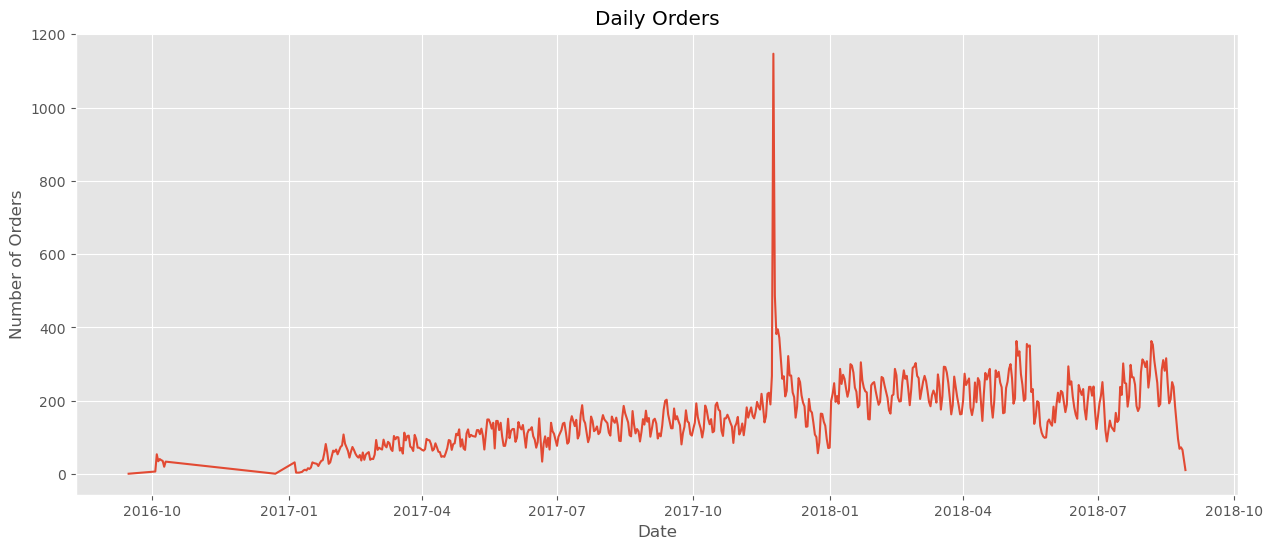

In [264]:
plt.figure(figsize=(15,6))

daily_orders.plot()

plt.title("Daily Orders")

plt.xlabel("Date")

plt.ylabel("Number of Orders")

plt.show()

Business Insight

growth

sudden drops

peaks

seasonality

Monthly Orders

In [265]:
monthly_orders = (
    master_df
    .groupby(master_df["order_purchase_timestamp"].dt.to_period("M"))
    ["order_id"]
    .nunique()
)

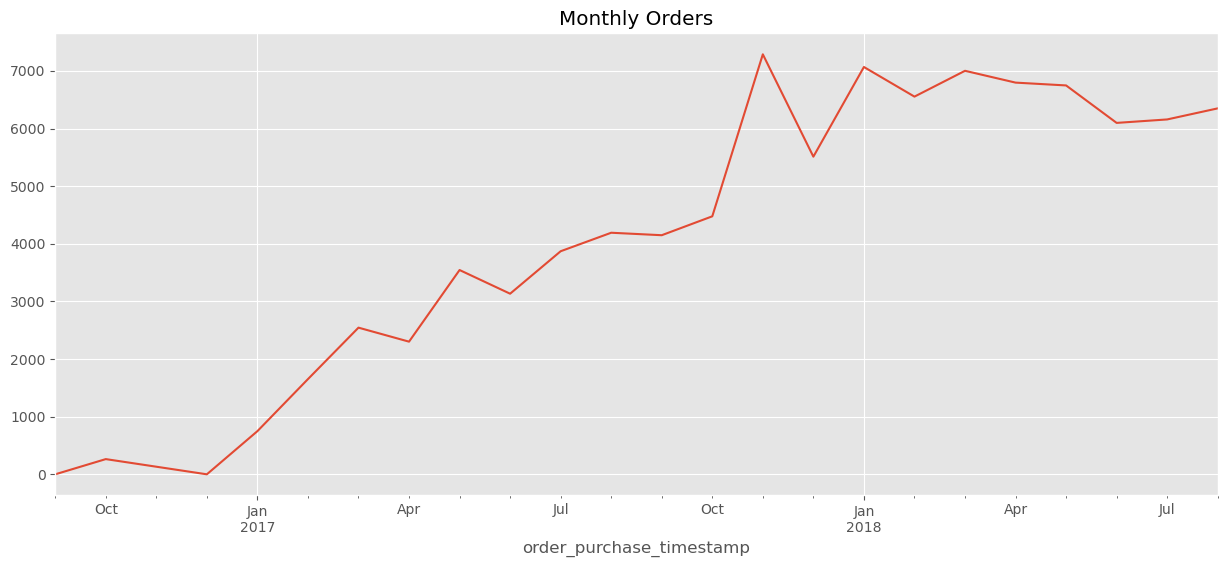

In [266]:
monthly_orders.plot(figsize=(15,6))

plt.title("Monthly Orders")

plt.show()

Revenue Analysis

Monthly Revenue

In [267]:
monthly_revenue = (
    master_df
    .groupby(master_df["order_purchase_timestamp"].dt.to_period("M"))
    ["revenue"]
    .sum()
)

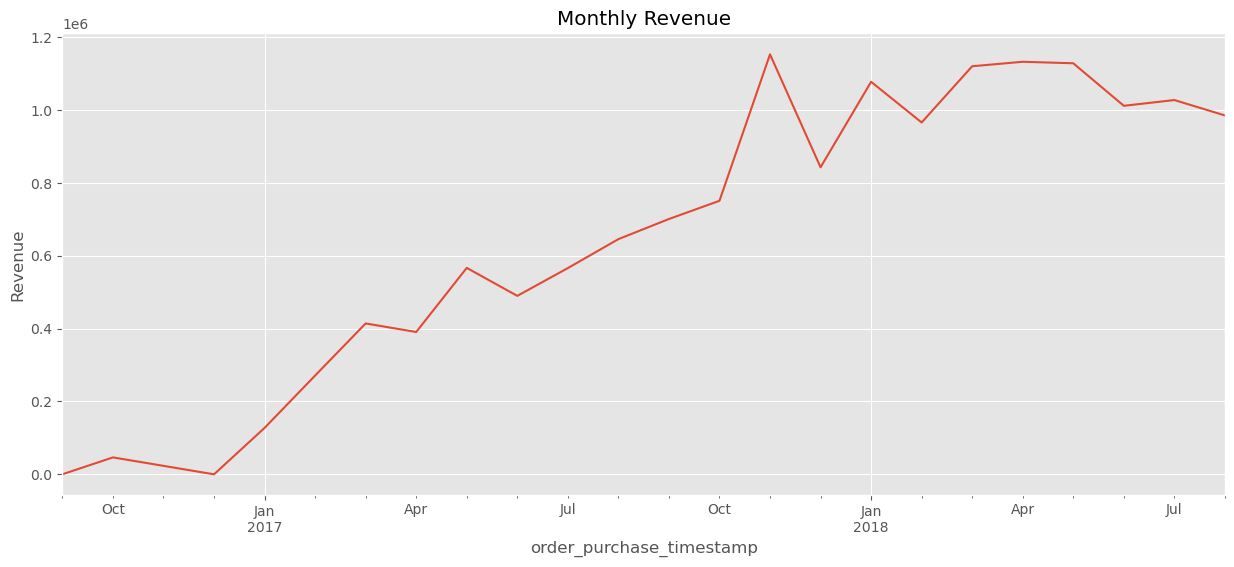

In [268]:
monthly_revenue.plot(figsize=(15,6))

plt.title("Monthly Revenue")

plt.ylabel("Revenue")

plt.show()

Top Revenue Months

In [269]:
monthly_revenue.sort_values(ascending=False).head(10)

order_purchase_timestamp
2017-11   1153364.20
2018-04   1132878.93
2018-05   1128774.52
2018-03   1120598.24
2018-01   1077887.46
2018-07   1027807.28
2018-06   1011978.29
2018-08    985491.64
2018-02    966168.41
2017-12    843078.29
Freq: M, Name: revenue, dtype: float64

In [270]:
aov = (
    master_df
    .groupby("order_id")
    ["revenue"]
    .sum()
    .mean()
)

print(aov)

159.82683876116835


Product Analysis
Most Sold Products

In [271]:
top_products = (
    master_df
    .groupby("product_id")
    .size()
    .sort_values(ascending=False)
    .head(20)
)

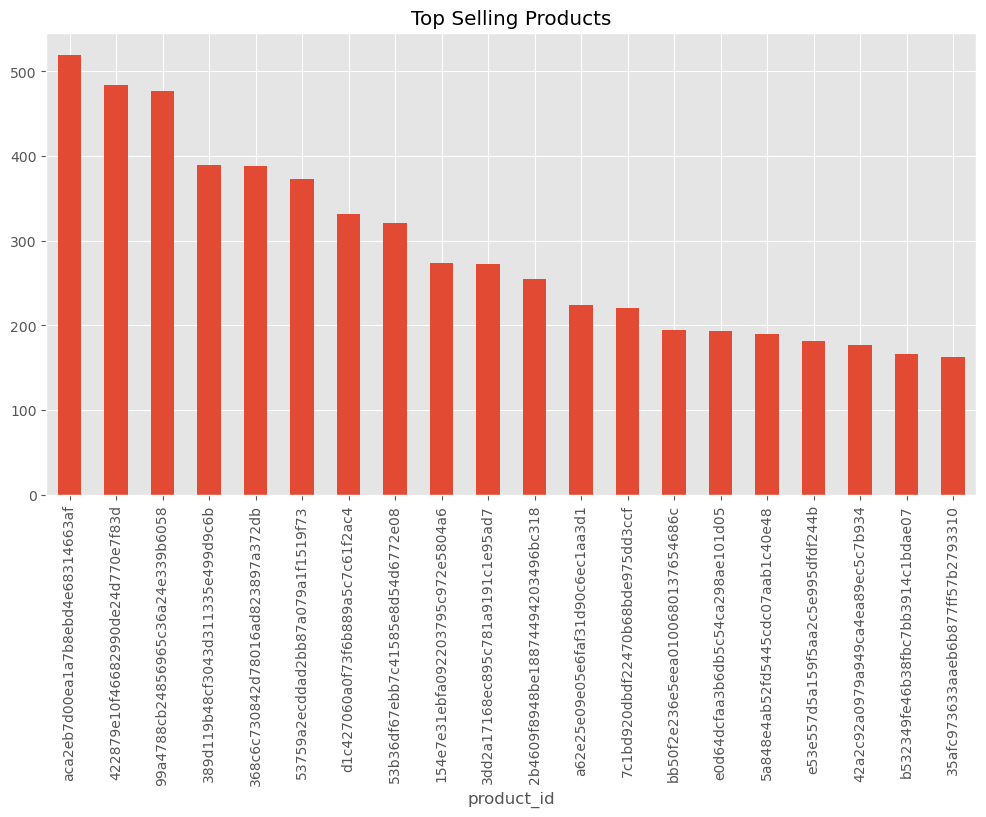

In [272]:
top_products.plot(kind="bar")

plt.title("Top Selling Products")

plt.show()

Highest Revenue Products

In [273]:
top_revenue_products = (
    master_df
    .groupby("product_id")
    ["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

Category Analysis

In [274]:
top_categories = (
    master_df
    .groupby("category")
    ["revenue"]
    .sum()
    .sort_values(ascending=False)
)

<Axes: xlabel='category'>

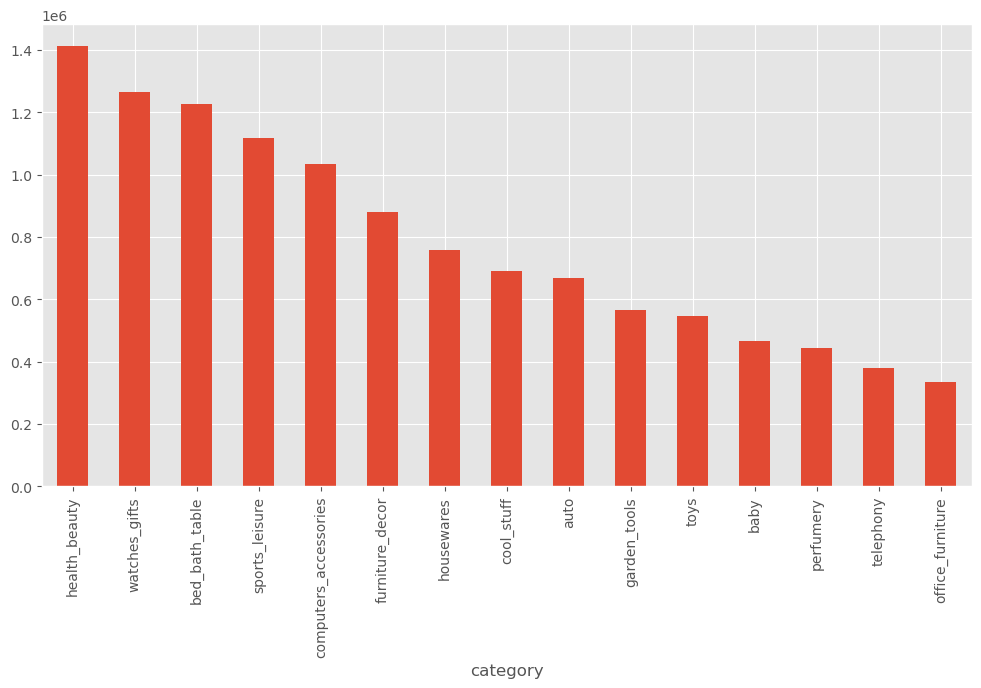

In [275]:
top_categories.head(15).plot(kind="bar")

Demand by Category

In [276]:
category_demand = (
    master_df
    .groupby("category")
    .size()
    .sort_values(ascending=False)
)

Average Freight

In [277]:
master_df["freight_value"].mean()

np.float64(19.94859787471528)

Freight Distribution

<Axes: xlabel='freight_value', ylabel='Count'>

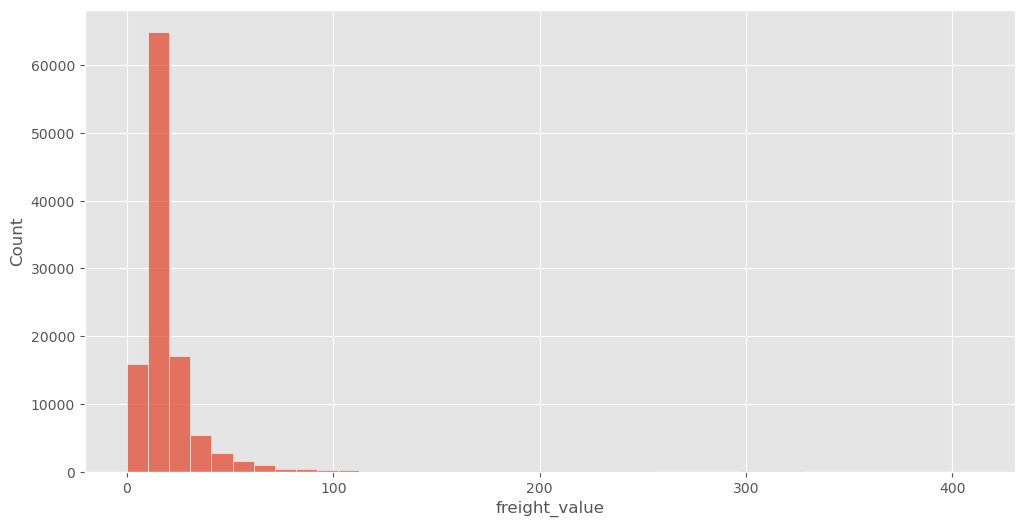

In [278]:
sns.histplot(master_df["freight_value"], bins=40)

Price vs Freight

<Axes: xlabel='price', ylabel='freight_value'>

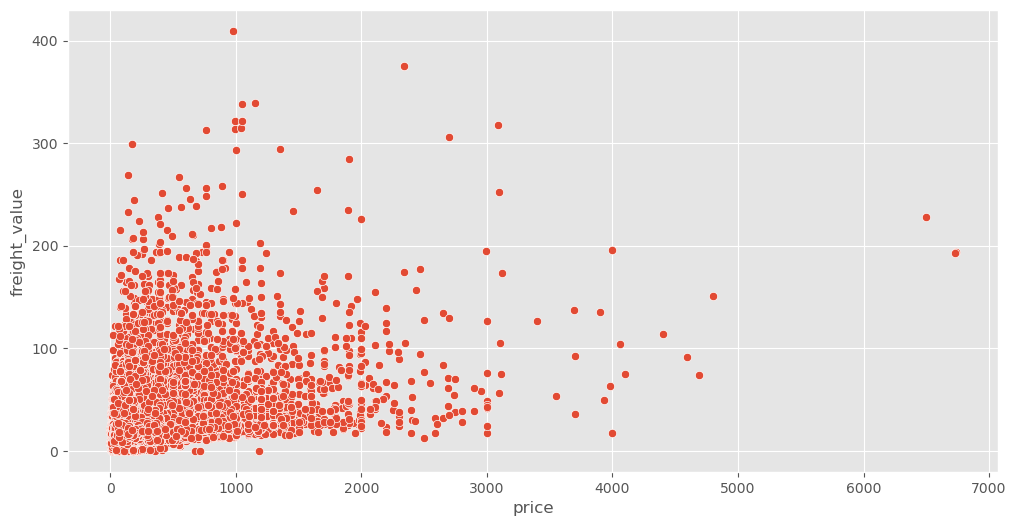

In [279]:
sns.scatterplot(
    data=master_df,
    x="price",
    y="freight_value"
)

Time Pattern Analysis

Orders by Month

In [280]:
master_df["month_name"].value_counts()

month_name
August       11939
May          11814
July         11379
March        10914
June         10499
April        10396
February      9376
January       8950
November      8475
December      6188
October       5527
September     4740
Name: count, dtype: int64

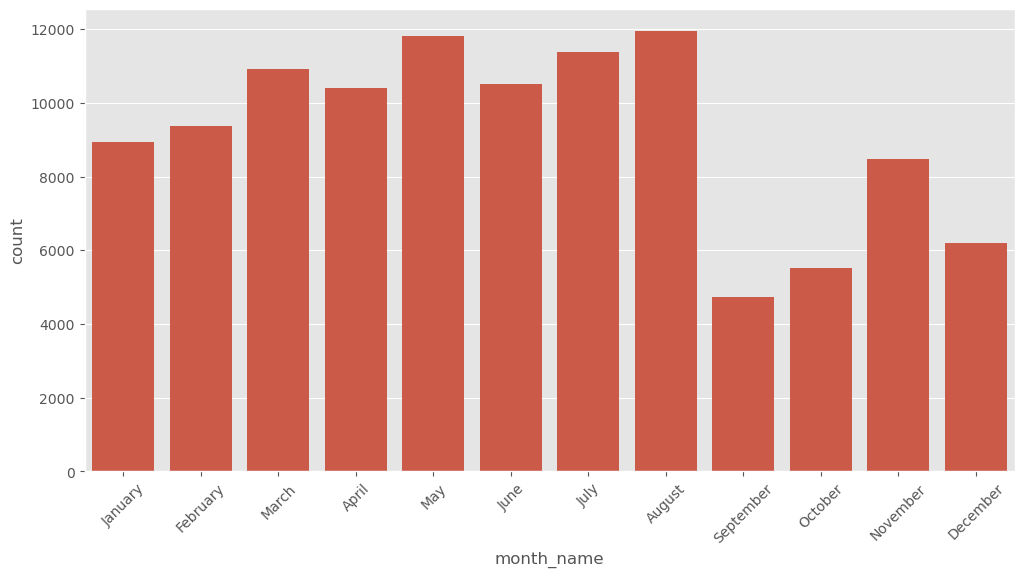

In [281]:
sns.countplot(
    data=master_df,
    x="month_name",
    order=[
        "January","February","March","April",
        "May","June","July","August",
        "September","October","November","December"
    ]
)

plt.xticks(rotation=45)

plt.show()

Orders by Weekday

<Axes: xlabel='day_name', ylabel='count'>

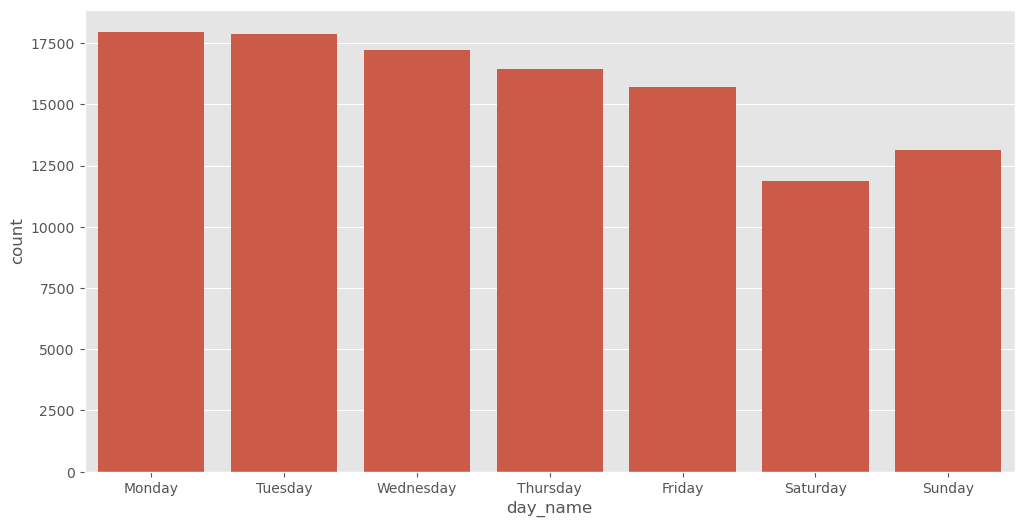

In [282]:
sns.countplot(
    data=master_df,
    x="day_name",
    order=[
        "Monday","Tuesday","Wednesday",
        "Thursday","Friday",
        "Saturday","Sunday"
    ]
)

Orders by Quarter

In [283]:
master_df.groupby("quarter")["order_id"].nunique()

quarter
1    25576
2    28630
3    24726
4    17546
Name: order_id, dtype: int64

Correlation & Outlier Analysis
Correlation Matrix

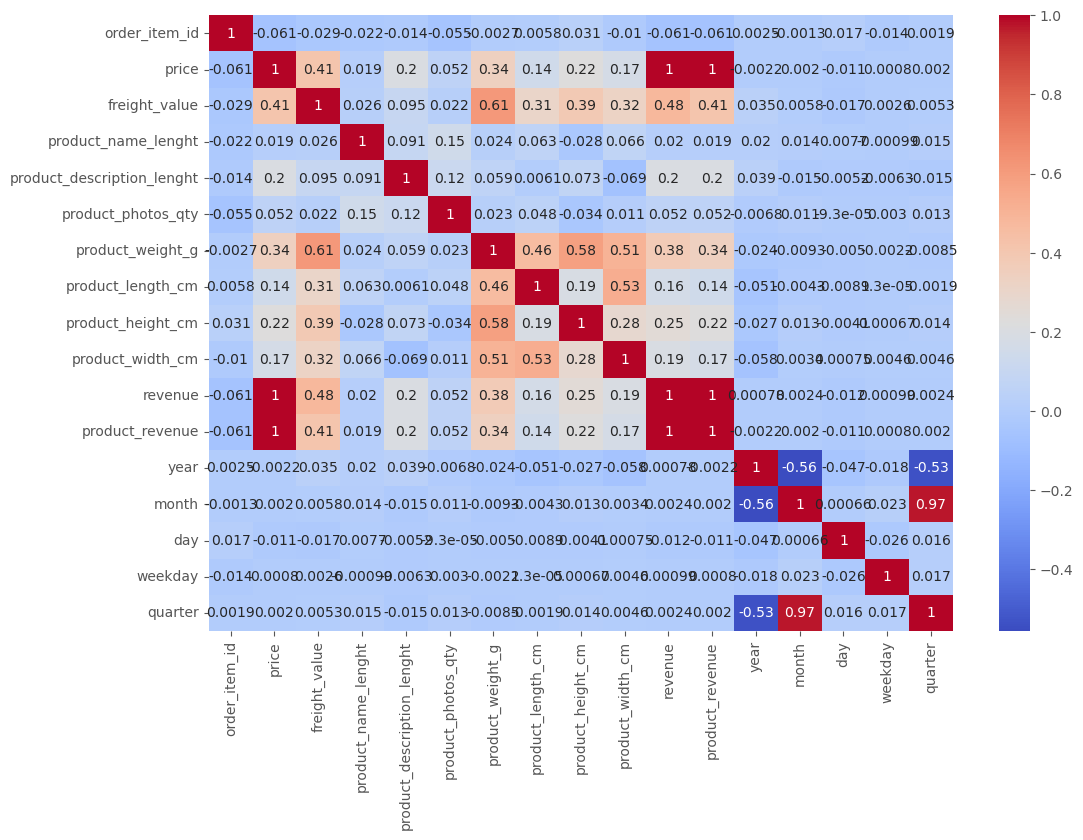

In [284]:
numeric = master_df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

Price Distribution

<Axes: xlabel='price'>

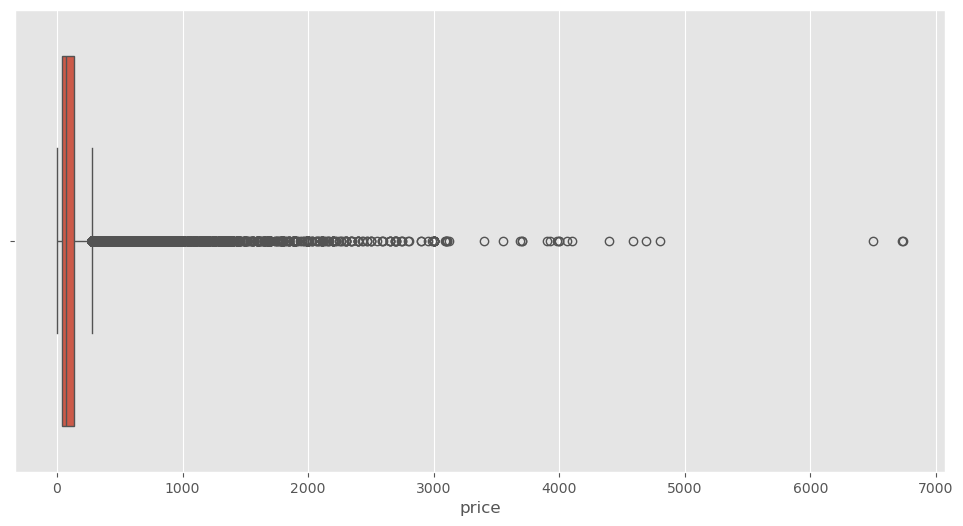

In [285]:
sns.boxplot(
    x=master_df["price"]
)

Revenue Distribution

<Axes: xlabel='revenue'>

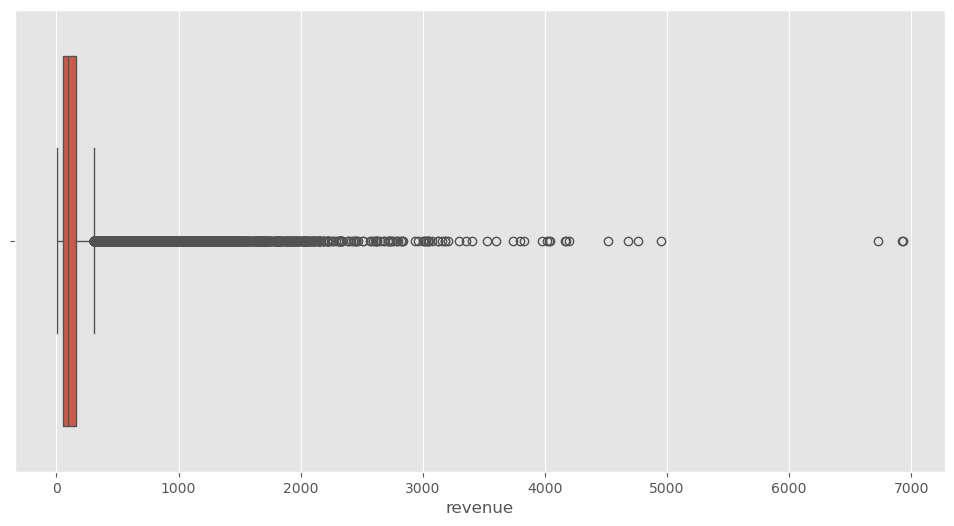

In [287]:
sns.boxplot(
    x=master_df["revenue"]
)

# PHASE 7: Time Series Dataset Creation

In [288]:
# Select Required Columns


forecast_df = master_df[
    [
        "order_purchase_timestamp",
        "category",
        "product_id",
        "price",
        "freight_value"
    ]
].copy()

Create Date Column

In [289]:
forecast_df["date"] = (
    forecast_df["order_purchase_timestamp"]
    .dt.normalize()
)

In [290]:
forecast_df["date"] = (
    forecast_df["order_purchase_timestamp"]
    .dt.date
)

In [291]:
# Aggregate Demand by Category


category_daily = (
    forecast_df
    .groupby(["date", "category"])
    .size()
    .reset_index(name="demand")
)

In [292]:
category_daily.head()

,date,category,demand
0,2016-09-15,health_beauty,3
1,2016-10-03,fashion_shoes,1
2,2016-10-03,furniture_decor,2
3,2016-10-03,sports_leisure,2
4,2016-10-03,toys,1


In [293]:
category_daily.shape

(18792, 3)

In [294]:
category_daily.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18792 entries, 0 to 18791
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      18792 non-null  object
 1   category  18792 non-null  object
 2   demand    18792 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 440.6+ KB


In [295]:
# Check Missing Dates


# Time series should ideally have continuous dates.



category_daily["date"].min()

category_daily["date"].max()

datetime.date(2018, 8, 29)

In [296]:
# Number of Categories


category_daily["category"].nunique()

72

In [300]:
# Demand Statistics


category_daily["demand"].describe()

count   18792.00
mean        5.86
std         7.21
min         1.00
25%         1.00
50%         3.00
75%         8.00
max       192.00
Name: demand, dtype: float64

In [301]:
# Highest Demand Categories


category_total = (
    category_daily
    .groupby("category")["demand"]
    .sum()
    .sort_values(ascending=False)
)

category_total.head(15)

category
bed_bath_table           10953
health_beauty             9465
sports_leisure            8431
furniture_decor           8160
computers_accessories     7644
housewares                6795
watches_gifts             5859
telephony                 4430
garden_tools              4268
auto                      4140
toys                      4030
cool_stuff                3718
perfumery                 3340
baby                      2982
electronics               2729
Name: demand, dtype: int64

In [302]:
# Select Categories for Forecasting
# Not every category has enough historical data.

# We should forecast only categories with sufficient observations.

# Example:

top_categories = (
    category_total
    .head(10)
    .index
)

In [303]:
forecast_data = (
    category_daily[
        category_daily["category"].isin(top_categories)
    ]
)

In [304]:
forecast_data.head()

,date,category,demand
0,2016-09-15,health_beauty,3
2,2016-10-03,furniture_decor,2
3,2016-10-03,sports_leisure,2
5,2016-10-03,watches_gifts,1
8,2016-10-04,auto,1


In [305]:
forecast_data.shape

(5901, 3)

In [306]:
forecast_data.to_csv(
    "data/forecast_dataset.csv",
    index=False
)

# PHASE 8: Feature Engineering for Time Series

In [ ]:
Objective

Transform the raw time series into a feature-rich dataset suitable for machine learning while avoiding data leakage.

Key principle: Every feature must be computable using only information available before the prediction date.

In [307]:
forecast_data

,date,category,demand
0,2016-09-15,health_beauty,3
2,2016-10-03,furniture_decor,2
3,2016-10-03,sports_leisure,2
5,2016-10-03,watches_gifts,1
8,2016-10-04,auto,1
...,...,...,...
18783,2018-08-28,watches_gifts,1
18784,2018-08-29,computers_accessories,1
18786,2018-08-29,health_beauty,7
18789,2018-08-29,sports_leisure,1


In [308]:
# Sort the Data
# This is mandatory before creating lag or rolling features.

forecast_data = forecast_data.sort_values(
    ["category", "date"]
).reset_index(drop=True)

In [ ]:
# Extract Calendar Features

In [309]:
forecast_data["date"].dtype

dtype('O')

In [310]:
forecast_data["date"] = pd.to_datetime(forecast_data["date"])

In [311]:
forecast_data["date"].dtype

dtype('<M8[ns]')

In [312]:
forecast_data["year"] = forecast_data["date"].dt.year
forecast_data["month"] = forecast_data["date"].dt.month
forecast_data["day"] = forecast_data["date"].dt.day
forecast_data["day_of_week"] = forecast_data["date"].dt.dayofweek
forecast_data["week_of_year"] = forecast_data["date"].dt.isocalendar().week.astype(int)
forecast_data["quarter"] = forecast_data["date"].dt.quarter
forecast_data["is_weekend"] = forecast_data["day_of_week"].isin([5, 6]).astype(int)
forecast_data["day_of_year"] = forecast_data["date"].dt.dayofyear

Create Lag Features
Lag features are among the most important predictors.

In [313]:
lags = [1, 7, 14, 30]

for lag in lags:
    forecast_data[f"lag_{lag}"] = (
        forecast_data
        .groupby("category")["demand"]
        .shift(lag)
    )

Rolling Statistics

In [314]:
forecast_data["rolling_mean_7"] = (
    forecast_data.groupby("category")["demand"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

forecast_data["rolling_mean_30"] = (
    forecast_data.groupby("category")["demand"]
    .transform(lambda x: x.shift(1).rolling(30).mean())
)

forecast_data["rolling_std_7"] = (
    forecast_data.groupby("category")["demand"]
    .transform(lambda x: x.shift(1).rolling(7).std())
)

Exponential Moving Average (EMA)

In [315]:
forecast_data["ema_7"] = (
    forecast_data.groupby("category")["demand"]
    .transform(lambda x: x.shift(1).ewm(span=7, adjust=False).mean())
)

forecast_data["ema_30"] = (
    forecast_data.groupby("category")["demand"]
    .transform(lambda x: x.shift(1).ewm(span=30, adjust=False).mean())
)

Demand Change Features

In [316]:
forecast_data["diff_1"] = (
    forecast_data.groupby("category")["demand"].diff(1)
)

forecast_data["pct_change_7"] = (
    forecast_data.groupby("category")["demand"].pct_change(7)
)

Cyclical Encoding

In [317]:
import numpy as np

forecast_data["month_sin"] = np.sin(
    2 * np.pi * forecast_data["month"] / 12
)

forecast_data["month_cos"] = np.cos(
    2 * np.pi * forecast_data["month"] / 12
)

forecast_data["dow_sin"] = np.sin(
    2 * np.pi * forecast_data["day_of_week"] / 7
)

forecast_data["dow_cos"] = np.cos(
    2 * np.pi * forecast_data["day_of_week"] / 7
)

Handle Missing Values from Feature Engineering
Lag and rolling features create missing values at the beginning of each category's history.

In [318]:
forecast_data.isnull().sum().sort_values(ascending=False)

lag_30             300
rolling_mean_30    300
lag_14             140
pct_change_7        70
rolling_std_7       70
lag_7               70
rolling_mean_7      70
diff_1              10
ema_30              10
ema_7               10
lag_1               10
dow_sin              0
month_cos            0
month_sin            0
date                 0
category             0
day_of_year          0
is_weekend           0
quarter              0
week_of_year         0
day_of_week          0
day                  0
month                0
year                 0
demand               0
dow_cos              0
dtype: int64

In [319]:
forecast_data = forecast_data.dropna().reset_index(drop=True)

In [320]:
forecast_data.info()
forecast_data.head()
forecast_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5601 entries, 0 to 5600
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             5601 non-null   datetime64[ns]
 1   category         5601 non-null   object        
 2   demand           5601 non-null   int64         
 3   year             5601 non-null   int32         
 4   month            5601 non-null   int32         
 5   day              5601 non-null   int32         
 6   day_of_week      5601 non-null   int32         
 7   week_of_year     5601 non-null   int64         
 8   quarter          5601 non-null   int32         
 9   is_weekend       5601 non-null   int64         
 10  day_of_year      5601 non-null   int32         
 11  lag_1            5601 non-null   float64       
 12  lag_7            5601 non-null   float64       
 13  lag_14           5601 non-null   float64       
 14  lag_30           5601 non-null   float64

,date,demand,year,month,day,day_of_week,week_of_year,quarter,is_weekend,day_of_year,lag_1,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_30,rolling_std_7,ema_7,ema_30,diff_1,pct_change_7,month_sin,month_cos,dow_sin,dow_cos
count,5601,5601.00,5601.00,5601.00,5601.00,5601.00,5601.00,5601.00,5601.00,5601.00,5601.00,5601.00,5601.00,5601.00,5601.00,5601.00,5601.00,5601.00,5601.00,5601.00,5601.00,5601.00,5601.00,5601.00,5601.00
mean,2017-11-20 12:56:25.966791680,12.35,2017.43,6.05,15.75,2.99,24.39,2.35,0.28,168.27,12.35,12.32,12.15,11.63,12.34,12.07,4.86,12.33,12.07,-0.00,0.31,0.08,-0.18,0.00,0.00
min,2017-01-30 00:00:00,1.00,2017.00,1.00,1.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.43,1.37,0.49,1.56,1.38,-102.00,-0.94,-1.00,-1.00,-0.97,-0.90
25%,2017-07-03 00:00:00,6.00,2017.00,4.00,8.00,1.00,13.00,2.00,0.00,92.00,6.00,6.00,6.00,5.00,7.00,7.03,2.82,6.93,7.27,-4.00,-0.33,-0.50,-0.87,-0.78,-0.90
50%,2017-11-21 00:00:00,10.00,2017.00,6.00,16.00,3.00,24.00,2.00,0.00,162.00,10.00,10.00,10.00,9.00,10.57,10.53,4.12,10.56,10.51,0.00,0.00,0.00,-0.50,0.00,-0.22
75%,2018-04-10 00:00:00,17.00,2018.00,8.00,23.00,5.00,34.00,3.00,1.00,233.00,17.00,17.00,16.00,16.00,16.00,16.03,5.79,16.01,16.12,3.00,0.50,0.87,0.50,0.78,0.62
max,2018-08-29 00:00:00,192.00,2018.00,12.00,31.00,6.00,52.00,4.00,1.00,365.00,192.00,192.00,192.00,192.00,70.43,36.17,65.81,71.13,37.48,158.00,27.00,1.00,1.00,0.97,1.00
std,NaN,9.53,0.49,3.07,8.74,2.00,13.36,1.02,0.45,93.72,9.52,9.53,9.50,9.38,7.58,6.71,3.90,7.50,6.65,7.76,1.25,0.71,0.68,0.71,0.71


Save the Engineered Dataset

In [321]:
forecast_data.to_csv(
    "data/forecast_features.csv",
    index=False
)

In [322]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
forecast_data["category_encoded"] = le.fit_transform(forecast_data["category"])

# PHASE 9: Baseline Forecast

In [323]:
# Sort the Dataset
# Sort by date and category


forecast_data = forecast_data.sort_values(
    by=["date", "category"]
).reset_index(drop=True)

# Verify
forecast_data.head()

,date,category,demand,year,month,day,day_of_week,week_of_year,quarter,is_weekend,day_of_year,lag_1,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_30,rolling_std_7,ema_7,ema_30,diff_1,pct_change_7,month_sin,month_cos,dow_sin,dow_cos,category_encoded
0,2017-01-30,furniture_decor,6,2017,1,30,0,5,1,0,30,7.00,12.00,5.00,2.00,8.00,7.37,4.08,7.61,7.05,-1.00,-0.50,0.50,0.87,0.00,1.00,3
1,2017-01-31,furniture_decor,15,2017,1,31,1,5,1,0,31,6.00,5.00,7.00,14.00,7.14,7.50,3.72,7.21,6.98,9.00,2.00,0.50,0.87,0.78,0.62,3
2,2017-02-01,furniture_decor,7,2017,2,1,2,5,1,0,32,15.00,7.00,7.00,8.00,8.57,7.53,4.58,9.16,7.50,-8.00,0.00,0.87,0.50,0.97,-0.22,3
3,2017-02-02,furniture_decor,9,2017,2,2,3,5,1,0,33,7.00,14.00,13.00,5.00,8.57,7.50,4.58,8.62,7.46,2.00,-0.36,0.87,0.50,0.43,-0.90,3
4,2017-02-02,health_beauty,9,2017,2,2,3,5,1,0,33,7.00,9.00,1.00,3.00,5.86,4.40,2.61,6.25,4.69,2.00,0.00,0.87,0.50,0.43,-0.90,5


In [324]:
# Check Date Range


print("Start Date :", forecast_data["date"].min())
print("End Date   :", forecast_data["date"].max())
print("Total Records :", len(forecast_data))

Start Date : 2017-01-30 00:00:00
End Date   : 2018-08-29 00:00:00
Total Records : 5601


In [325]:
# Chronological Train-Test Split (80:20)

split_index = int(len(forecast_data) * 0.80)

train_master = forecast_data.iloc[:split_index].copy()
test_master = forecast_data.iloc[split_index:].copy()

print("Train Shape :", train_master.shape)
print("Test Shape  :", test_master.shape)

Train Shape : (4480, 27)
Test Shape  : (1121, 27)


In [326]:
# Verify No Data Leakage


print("Train Start :", train_master["date"].min())
print("Train End   :", train_master["date"].max())

print()

print("Test Start  :", test_master["date"].min())
print("Test End    :", test_master["date"].max())

Train Start : 2017-01-30 00:00:00
Train End   : 2018-05-08 00:00:00

Test Start  : 2018-05-08 00:00:00
Test End    : 2018-08-29 00:00:00


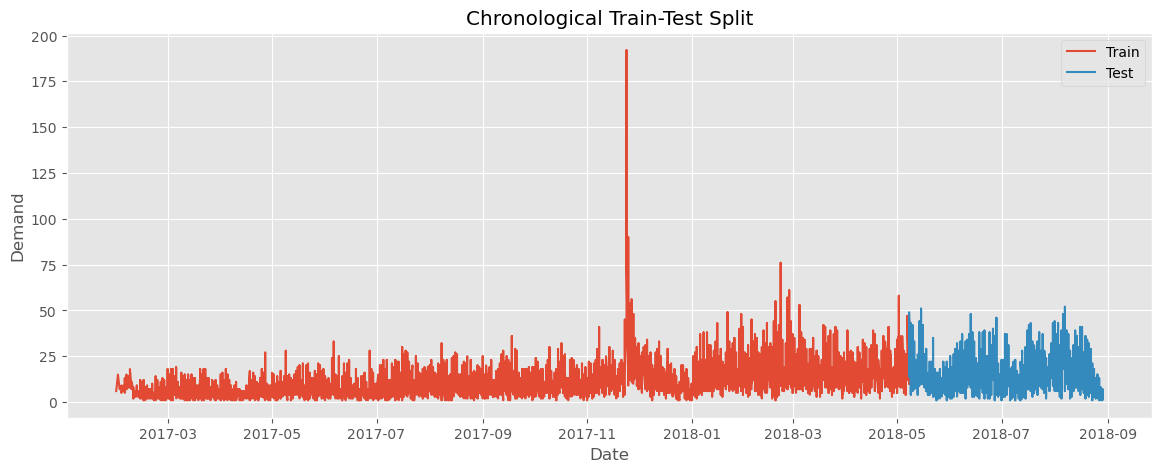

In [327]:
# Visual Verification


import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

plt.plot(
    train_master["date"],
    train_master["demand"],
    label="Train"
)

plt.plot(
    test_master["date"],
    test_master["demand"],
    label="Test"
)

plt.title("Chronological Train-Test Split")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()

In [328]:
# Save the Split


train_master.to_csv("train_master.csv", index=False)
test_master.to_csv("test_master.csv", index=False)

# PHASE 10 – Feature Selection & Evaluation Framework

Define Features

In [329]:
features = [
    "category_encoded",
    "year",
    "month",
    "day",
    "day_of_week",
    "week_of_year",
    "quarter",
    "is_weekend",
    "day_of_year",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_30",
    "rolling_std_7",
    "ema_7",
    "ema_30",
    "diff_1",
    "pct_change_7",
    "month_sin",
    "month_cos",
    "dow_sin",
    "dow_cos"
]

target = "demand"

Create Train/Test Matrices

In [330]:
X_train = train_master[features]
X_test = test_master[features]

y_train = train_master[target]
y_test = test_master[target]

print(X_train.shape)
print(X_test.shape)

(4480, 24)
(1121, 24)


Check Missing Values

In [331]:
print("Training Missing Values")
print(X_train.isnull().sum().sum())

print()

print("Testing Missing Values")
print(X_test.isnull().sum().sum())

Training Missing Values
0

Testing Missing Values
0


Create a Common Evaluation Function

In [333]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

results = []

def evaluate_model(model_name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    actual = np.array(y_true)
    pred = np.array(y_pred)

    mask = actual != 0

    mape = (
        np.mean(
            np.abs((actual[mask] - pred[mask]) / actual[mask])
        ) * 100
    )

    wape = (
        np.sum(np.abs(actual - pred))
        / np.sum(actual)
    ) * 100

    results.append({
        "Model": model_name,
        "MAE": round(mae, 3),
        "RMSE": round(rmse, 3),
        "R2": round(r2, 3),
        "MAPE": round(mape, 2),
        "WAPE": round(wape, 2)
    })

    print(f"{model_name} Completed")

Verify Everything

In [334]:
print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

print()

print("Number of Features :", X_train.shape[1])

Training Samples : 4480
Testing Samples  : 1121

Number of Features : 24


# PHASE 11 – Linear Regression & Decision Tree Regression

In [335]:
# Model 1 — Linear Regression

from sklearn.linear_model import LinearRegression

In [336]:
# Train Model
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [337]:
# Prediction


lr_pred = lr_model.predict(X_test)

In [338]:
# Evaluation


evaluate_model(
    "Linear Regression",
    y_test,
    lr_pred
)

Linear Regression Completed


In [339]:
# Model 2 — Decision Tree


from sklearn.tree import DecisionTreeRegressor

In [340]:
# Train

dt_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

,criterion,'squared_error'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [341]:
# Prediction


dt_pred = dt_model.predict(X_test)

In [342]:
# Evaluation


evaluate_model(
    "Decision Tree",
    y_test,
    dt_pred
)

Decision Tree Completed


In [343]:
# View Results


results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2,MAPE,WAPE
0,Linear Regression,0.00,0.00,1.00,0.00,0.00
1,Decision Tree,1.04,1.98,0.96,6.78,6.76


In [344]:
# Compare Predictions Visually


comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Linear Regression": lr_pred,
    "Decision Tree": dt_pred
})

comparison.head(10)

,Actual,Linear Regression,Decision Tree
0,25,25.00,26.33
1,14,14.00,14.73
2,49,49.00,44.00
3,14,14.00,13.36
4,28,28.00,22.73
5,24,24.00,22.80
6,33,33.00,28.40
7,4,4.00,4.00
8,43,43.00,45.00
9,23,23.00,22.73


# PHASE 12 – Random Forest Regression

Business Objective
Random Forest combines multiple decision trees to improve prediction accuracy and reduce overfitting.
In retail demand forecasting, it can capture complex, non-linear relationships between lag features,
seasonal effects, and demand.

In [345]:
from sklearn.ensemble import RandomForestRegressor

In [346]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [347]:
rf_pred = rf_model.predict(X_test)

In [348]:
evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)

Random Forest Completed


In [349]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="RMSE"
).reset_index(drop=True)

,Model,MAE,RMSE,R2,MAPE,WAPE
0,Linear Regression,0.00,0.00,1.00,0.00,0.00
1,Random Forest,0.54,1.12,0.99,4.24,3.49
2,Decision Tree,1.04,1.98,0.96,6.78,6.76


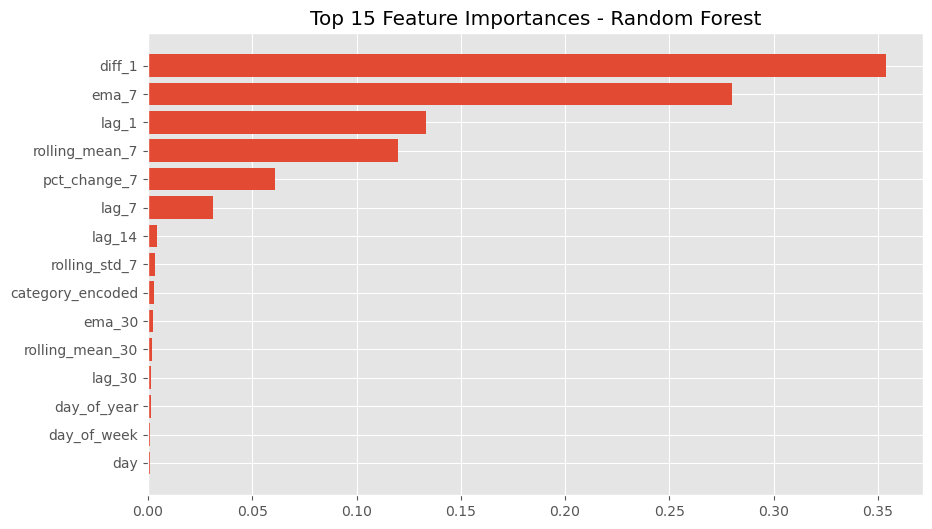

In [350]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:15],
    importance["Importance"][:15]
)

plt.title("Top 15 Feature Importances - Random Forest")
plt.gca().invert_yaxis()

plt.show()

# PHASE 13 – XGBoost Regression

In [351]:
from xgboost import XGBRegressor

In [352]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [353]:
xgb_pred = xgb_model.predict(X_test)

In [354]:
evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred
)

XGBoost Completed


In [355]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="RMSE"
).reset_index(drop=True)

,Model,MAE,RMSE,R2,MAPE,WAPE
0,Linear Regression,0.00,0.00,1.00,0.00,0.00
1,XGBoost,0.60,0.98,0.99,4.86,3.89
2,Random Forest,0.54,1.12,0.99,4.24,3.49
3,Decision Tree,1.04,1.98,0.96,6.78,6.76


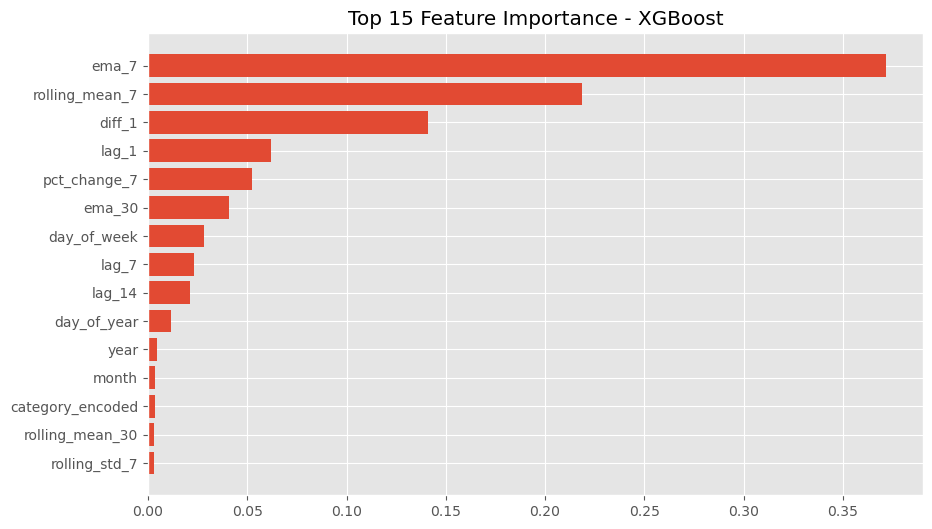

In [356]:
# Feature Importance


importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:15],
    importance["Importance"][:15]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Feature Importance - XGBoost")

plt.show()

# PHASE 14 – LightGBM Regression

Business Objective
Train a LightGBM Regressor to forecast retail demand efficiently.
LightGBM is optimized for speed and memory usage and is commonly used for large tabular datasets.

In [357]:
from lightgbm import LGBMRegressor

In [358]:
lgb_model = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001775 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2201
[LightGBM] [Info] Number of data points in the train set: 4480, number of used features: 24
[LightGBM] [Info] Start training from score 11.584152
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [359]:
lgb_pred = lgb_model.predict(X_test)

In [360]:
evaluate_model(
    "LightGBM",
    y_test,
    lgb_pred
)

LightGBM Completed


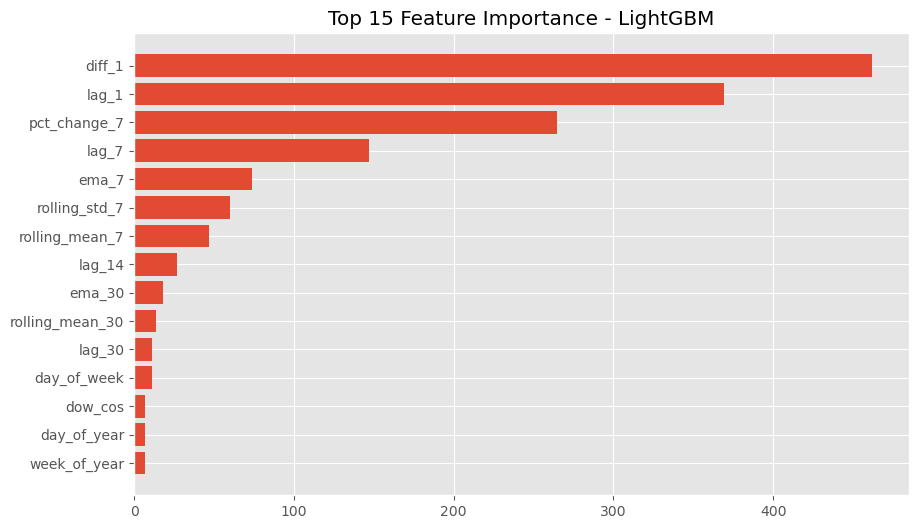

In [361]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": lgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:15],
    importance["Importance"][:15]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Feature Importance - LightGBM")

plt.show()

# PHASE 15 – CatBoost Regression

Business Objective
Train a CatBoost Regressor to forecast retail demand and compare its performance with Linear Regression,
Decision Tree, Random Forest, XGBoost, and LightGBM.

In [362]:
from catboost import CatBoostRegressor

In [363]:
# Train the Model


cat_model = CatBoostRegressor(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    random_seed=42,
    verbose=0
)

cat_model.fit(X_train, y_train)

CatBoostRegressor(depth=6, iterations=100, learning_rate=0.1, loss_function='RMSE', random_seed=42, verbose=0)

In [364]:
# Prediction


cat_pred = cat_model.predict(X_test)

In [366]:
# Evaluation

evaluate_model(
    "CatBoost",
    y_test,
    cat_pred
)

CatBoost Completed


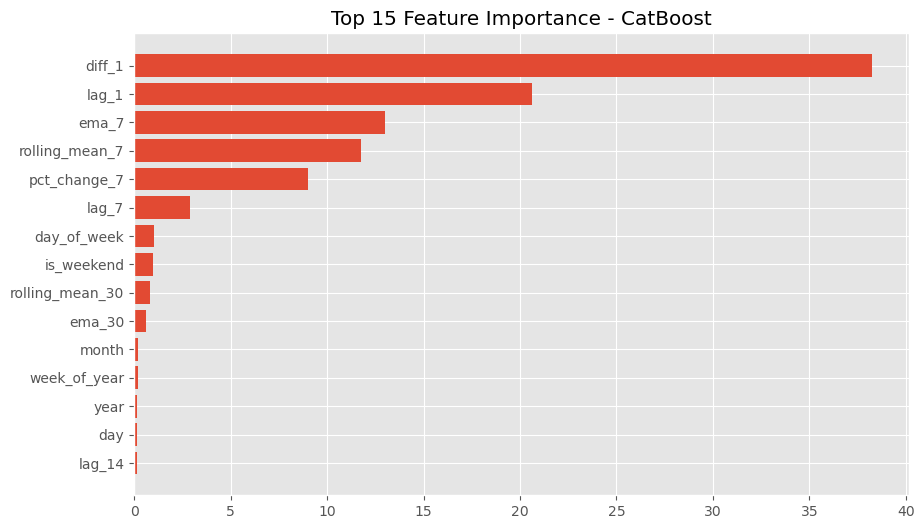

In [367]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": cat_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:15],
    importance["Importance"][:15]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Feature Importance - CatBoost")

plt.show()

# PHASE 16 – Model Comparison & Best Model Selection

Business Objective

Compare all trained machine learning models using the same evaluation metrics and identify
the best-performing model for retail demand forecasting.

In [368]:
results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2,MAPE,WAPE
0,Linear Regression,0.00,0.00,1.00,0.00,0.00
1,Decision Tree,1.04,1.98,0.96,6.78,6.76
2,Random Forest,0.54,1.12,0.99,4.24,3.49
3,XGBoost,0.60,0.98,0.99,4.86,3.89
4,LightGBM,0.71,1.40,0.98,5.64,4.60
5,CatBoost,1.14,1.58,0.97,12.42,7.39
6,CatBoost,1.14,1.58,0.97,12.42,7.39


In [369]:
results_df = results_df.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

results_df

,Model,MAE,RMSE,R2,MAPE,WAPE
0,Linear Regression,0.00,0.00,1.00,0.00,0.00
1,XGBoost,0.60,0.98,0.99,4.86,3.89
2,Random Forest,0.54,1.12,0.99,4.24,3.49
3,LightGBM,0.71,1.40,0.98,5.64,4.60
4,CatBoost,1.14,1.58,0.97,12.42,7.39
5,CatBoost,1.14,1.58,0.97,12.42,7.39
6,Decision Tree,1.04,1.98,0.96,6.78,6.76


In [370]:
best_model = results_df.iloc[0]

print(best_model)

Model    Linear Regression
MAE                   0.00
RMSE                  0.00
R2                    1.00
MAPE                  0.00
WAPE                  0.00
Name: 0, dtype: object


Visualize RMSE

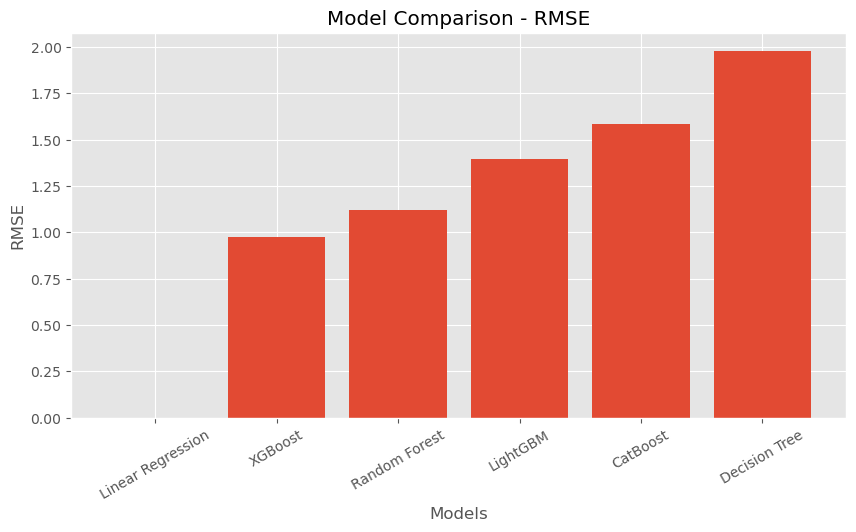

In [371]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    results_df["Model"],
    results_df["RMSE"]
)

plt.title("Model Comparison - RMSE")
plt.xlabel("Models")
plt.ylabel("RMSE")

plt.xticks(rotation=30)

plt.show()

Visualize RMSE

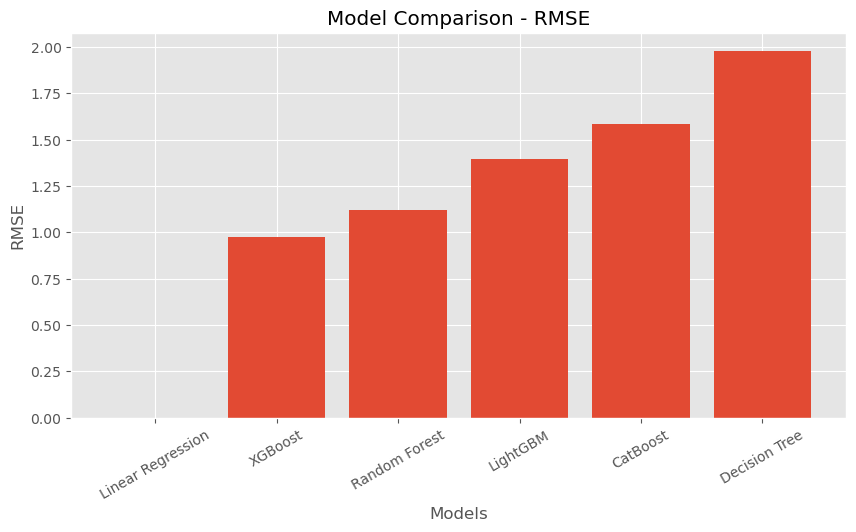

In [372]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    results_df["Model"],
    results_df["RMSE"]
)

plt.title("Model Comparison - RMSE")
plt.xlabel("Models")
plt.ylabel("RMSE")

plt.xticks(rotation=30)

plt.show()

Visualize MAE

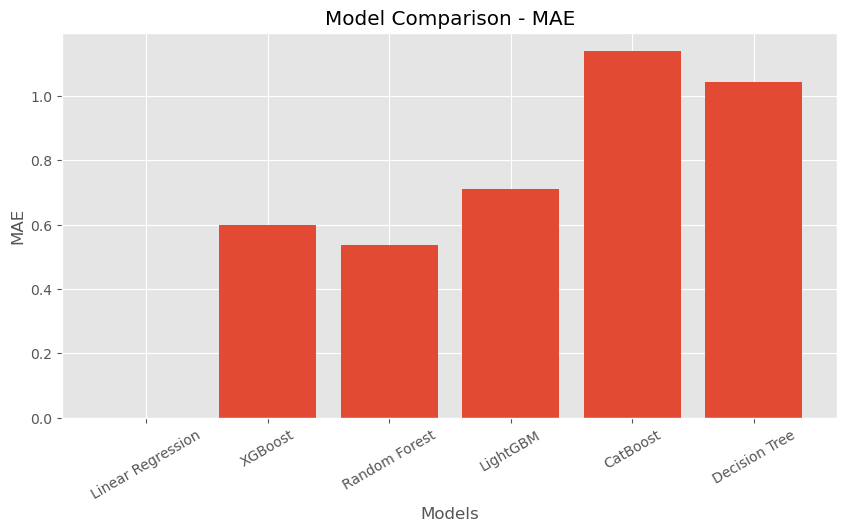

In [373]:
plt.figure(figsize=(10,5))

plt.bar(
    results_df["Model"],
    results_df["MAE"]
)

plt.title("Model Comparison - MAE")
plt.xlabel("Models")
plt.ylabel("MAE")

plt.xticks(rotation=30)

plt.show()

Visualize R²

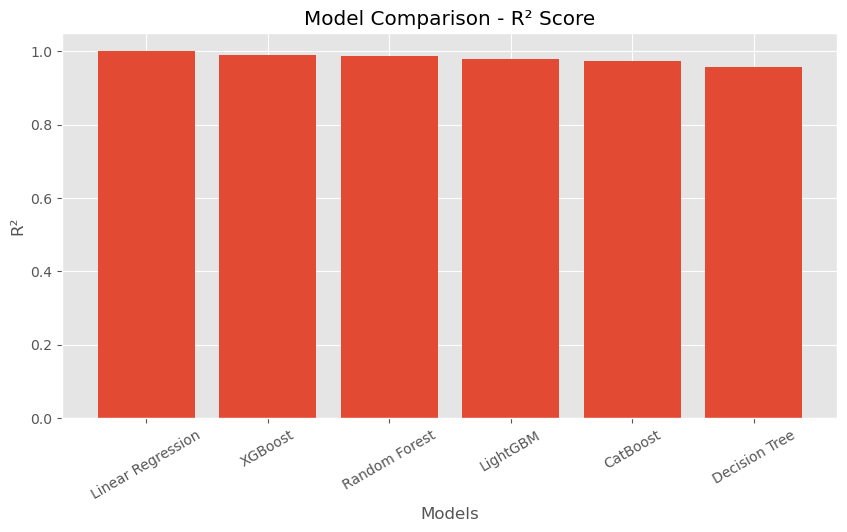

In [374]:
plt.figure(figsize=(10,5))

plt.bar(
    results_df["Model"],
    results_df["R2"]
)

plt.title("Model Comparison - R² Score")
plt.xlabel("Models")
plt.ylabel("R²")

plt.xticks(rotation=30)

plt.show()

Save Results

In [376]:
results_df.to_csv(
    "model_comparison_results.csv",
    index=False
)

results_df

,Model,MAE,RMSE,R2,MAPE,WAPE
0,Linear Regression,0.00,0.00,1.00,0.00,0.00
1,XGBoost,0.60,0.98,0.99,4.86,3.89
2,Random Forest,0.54,1.12,0.99,4.24,3.49
3,LightGBM,0.71,1.40,0.98,5.64,4.60
4,CatBoost,1.14,1.58,0.97,12.42,7.39
5,CatBoost,1.14,1.58,0.97,12.42,7.39
6,Decision Tree,1.04,1.98,0.96,6.78,6.76


# PHASE 17 – Classical Time Series Forecasting (ARIMA, SARIMA & Prophet)

Business Objective
Forecast demand for one product category using classical time series models and compare their forecasting performance.

In [377]:
category_counts = forecast_data["category"].value_counts()

category_counts.head(10)

category
furniture_decor          574
sports_leisure           573
health_beauty            572
bed_bath_table           567
computers_accessories    563
housewares               556
telephony                554
garden_tools             552
auto                     549
watches_gifts            541
Name: count, dtype: int64

In [378]:
# Select the Top Category

top_category = category_counts.idxmax()

print("Selected Category:", top_category)

Selected Category: furniture_decor


In [379]:
# Create the Time Series Dataset

ts_data = forecast_data[
    forecast_data["category"] == top_category
].copy()

In [380]:
# Keep Only Required Columns

ts_data = ts_data[
    ["date", "demand"]
]

In [381]:
# Sort by Date

ts_data = ts_data.sort_values(
    "date"
).reset_index(drop=True)

In [382]:
# Set Date Index

ts_data["date"] = pd.to_datetime(
    ts_data["date"]
)

ts_data.set_index(
    "date",
    inplace=True
)

In [383]:
# Ensure Daily Frequency

ts_data = ts_data.asfreq("D")

In [385]:
# Fill Missing Days

ts_data["demand"] = ts_data[
    "demand"
].fillna(0)

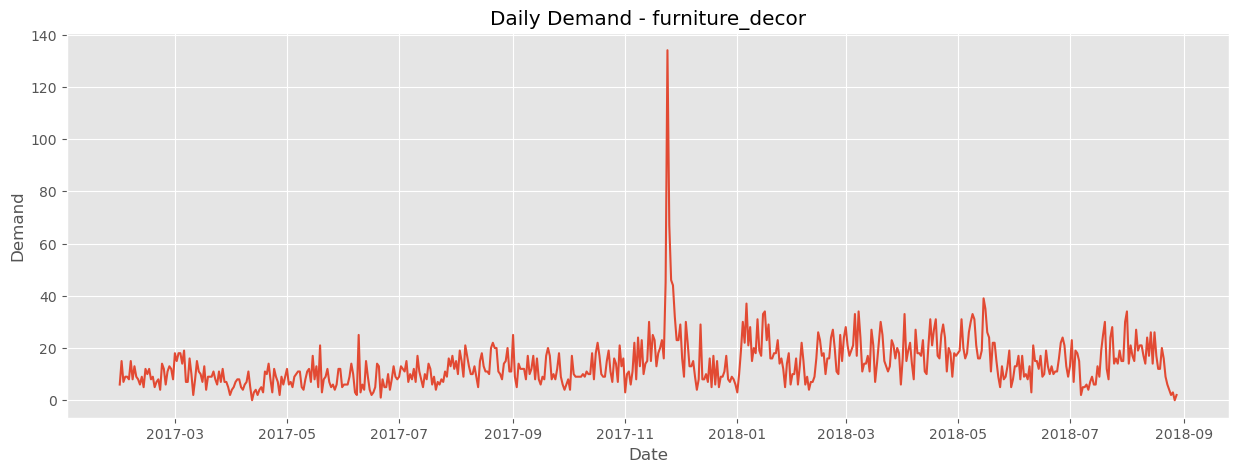

In [386]:
# Visualize the Series

import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    ts_data.index,
    ts_data["demand"]
)

plt.title(
    f"Daily Demand - {top_category}"
)

plt.xlabel("Date")

plt.ylabel("Demand")

plt.show()

In [387]:
# Chronological Split

split = int(len(ts_data) * 0.80)

train_ts = ts_data.iloc[:split]

test_ts = ts_data.iloc[split:]

print(train_ts.shape)

print(test_ts.shape)

(460, 1)
(116, 1)


# PHASE 18 – Time Series Diagnostics & Stationarity Analysis

Business Objective

Analyze the selected category's demand series to determine whether it is stationary and identify any
trend or seasonality before fitting ARIMA, SARIMA, and Prophet models.

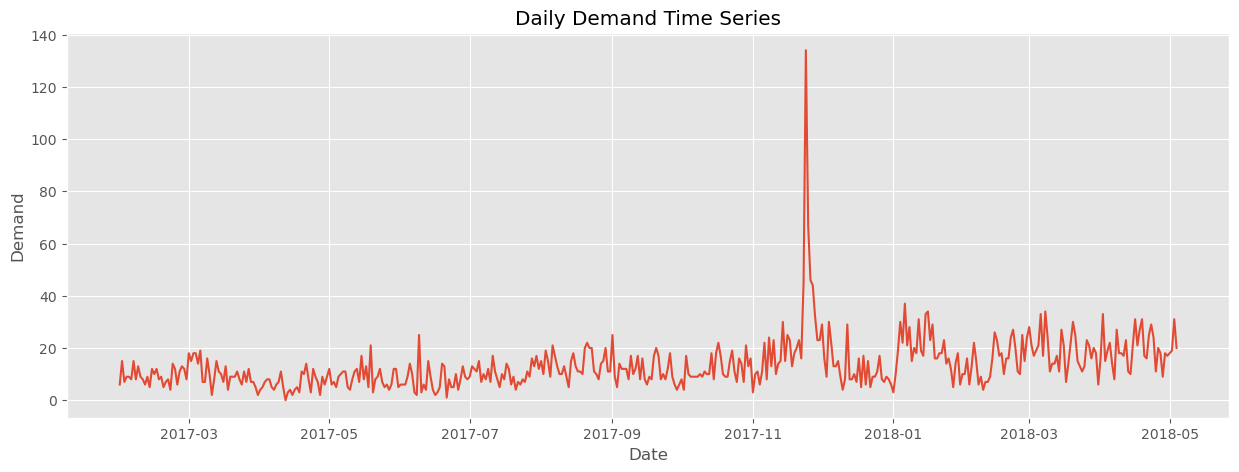

In [388]:
# Plot the Time Series


plt.figure(figsize=(15,5))

plt.plot(train_ts.index, train_ts["demand"])

plt.title("Daily Demand Time Series")
plt.xlabel("Date")
plt.ylabel("Demand")

plt.show()

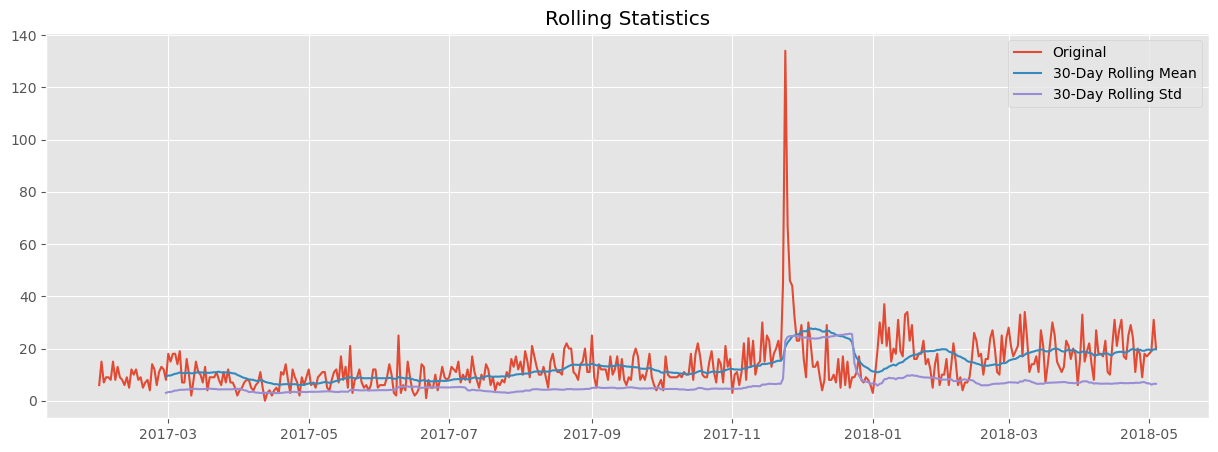

In [389]:
# Rolling Mean & Rolling Standard Deviation


rolling_mean = train_ts["demand"].rolling(window=30).mean()
rolling_std = train_ts["demand"].rolling(window=30).std()

plt.figure(figsize=(15,5))

plt.plot(train_ts["demand"], label="Original")
plt.plot(rolling_mean, label="30-Day Rolling Mean")
plt.plot(rolling_std, label="30-Day Rolling Std")

plt.legend()
plt.title("Rolling Statistics")

plt.show()

In [390]:
# Augmented Dickey-Fuller (ADF) Test


from statsmodels.tsa.stattools import adfuller

result = adfuller(train_ts["demand"])

print("ADF Statistic :", result[0])
print("p-value       :", result[1])

print()

for key, value in result[4].items():
    print(key, value)

ADF Statistic : -3.6139736788913353
p-value       : 0.005499432290433287

1% -3.444965543297668
5% -2.8679842369272976
10% -2.5702025382716047


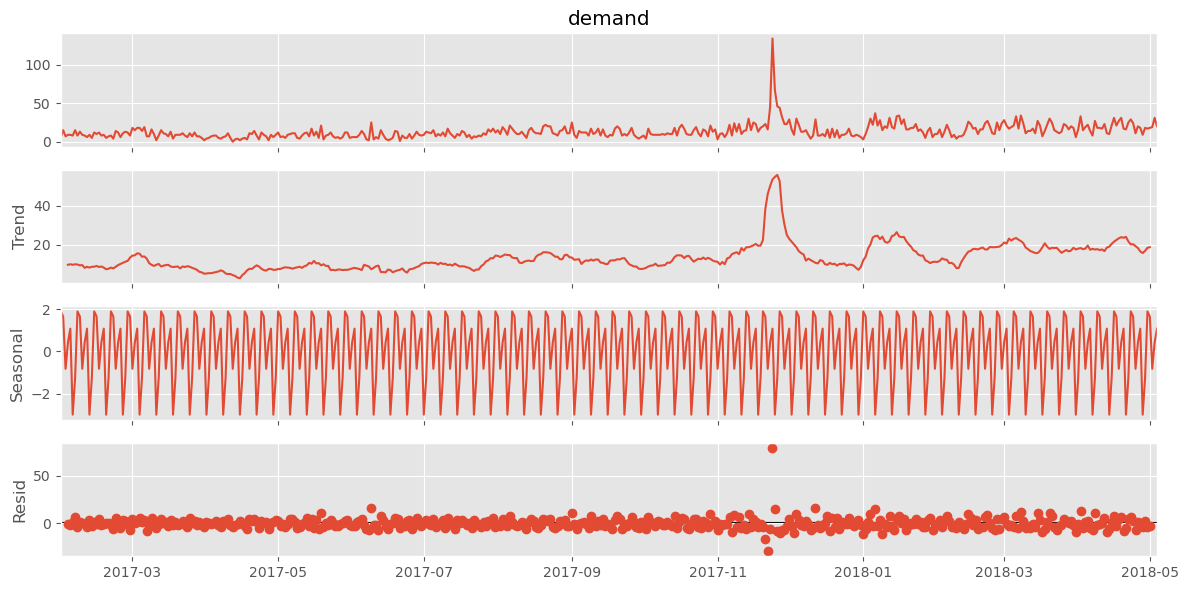

In [391]:
# Seasonal Decomposition


from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    train_ts["demand"],
    model="additive",
    period=7
)

decomposition.plot()

plt.show()

<Figure size 1000x500 with 0 Axes>

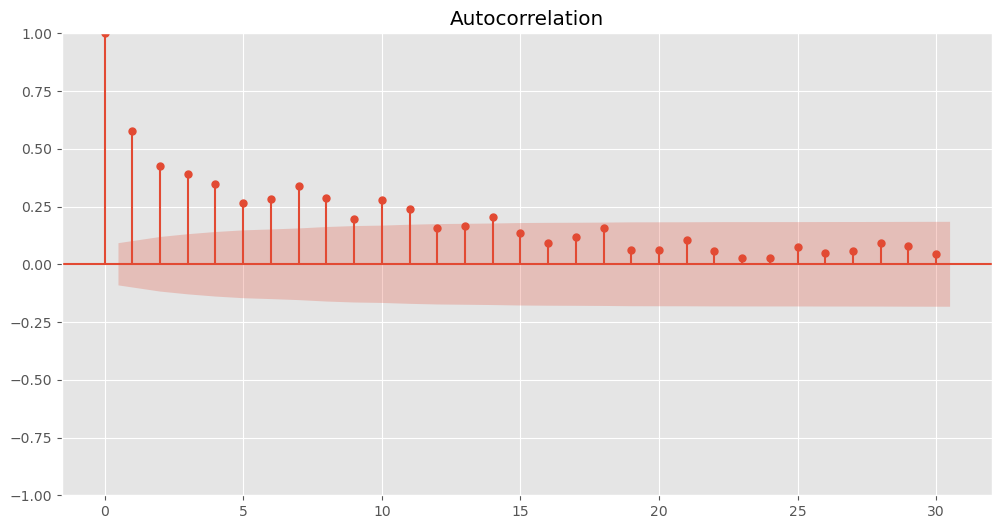

In [392]:
# ACF Plot


from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10,5))

plot_acf(
    train_ts["demand"],
    lags=30
)

plt.show()

<Figure size 1000x500 with 0 Axes>

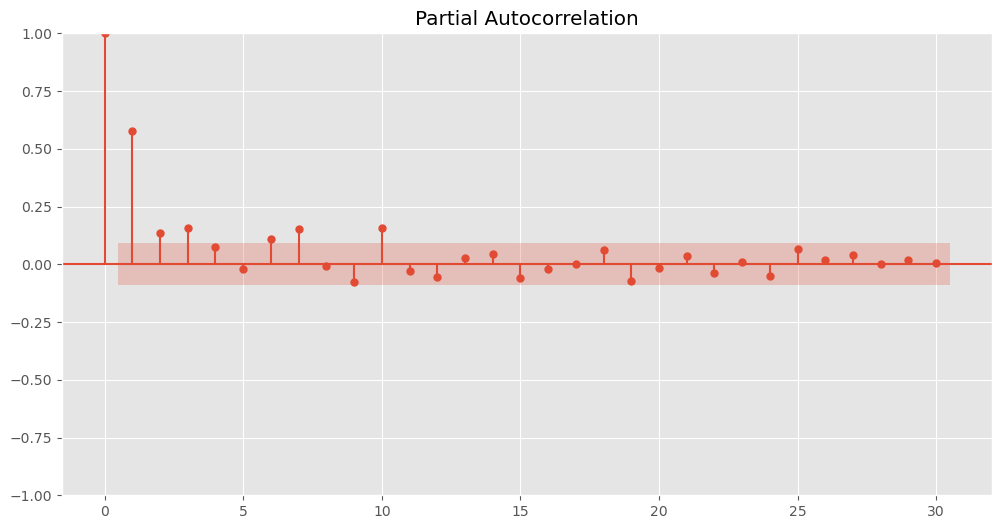

In [393]:
# PACF Plot


from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(10,5))

plot_pacf(
    train_ts["demand"],
    lags=30
)

plt.show()

# PHASE 19 – ARIMA Model

In [394]:
# Import Library


from statsmodels.tsa.arima.model import ARIMA

In [395]:
# Train the Model


arima_model = ARIMA(
    train_ts["demand"],
    order=(1, 0, 1)
)

arima_fit = arima_model.fit()

In [396]:
# Model Summary


print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                 demand   No. Observations:                  460
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -1592.998
Date:                Thu, 23 Jul 2026   AIC                           3193.995
Time:                        00:24:51   BIC                           3210.520
Sample:                    01-30-2017   HQIC                          3200.502
                         - 05-04-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.4331      1.733      7.753      0.000      10.037      16.829
ar.L1          0.8330      0.046     18.000      0.000       0.742       0.924
ma.L1         -0.4194      0.084     -4.983      0.0

In [397]:
# Forecast Test Period


arima_pred = arima_fit.forecast(
    steps=len(test_ts)
)

Evaluate Performance

In [398]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(
    test_ts["demand"],
    arima_pred
)

rmse = np.sqrt(
    mean_squared_error(
        test_ts["demand"],
        arima_pred
    )
)

r2 = r2_score(
    test_ts["demand"],
    arima_pred
)

actual = test_ts["demand"].values
pred = arima_pred.values

mask = actual != 0

mape = np.mean(
    np.abs(
        (actual[mask] - pred[mask]) /
        actual[mask]
    )
) * 100

wape = (
    np.sum(np.abs(actual - pred))
    /
    np.sum(actual)
) * 100

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")
print(f"MAPE : {mape:.2f}%")
print(f"WAPE : {wape:.2f}%")

MAE  : 6.106
RMSE : 7.840
R²   : 0.022
MAPE : 62.16%
WAPE : 39.86%


Plot Forecast

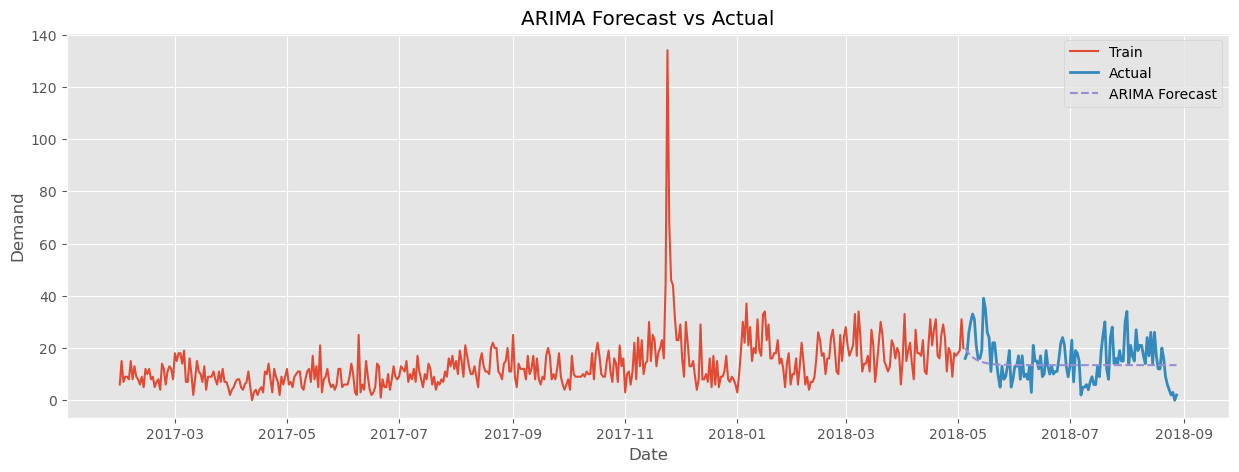

In [399]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    train_ts.index,
    train_ts["demand"],
    label="Train"
)

plt.plot(
    test_ts.index,
    test_ts["demand"],
    label="Actual",
    linewidth=2
)

plt.plot(
    test_ts.index,
    arima_pred,
    label="ARIMA Forecast",
    linestyle="--"
)

plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()

plt.show()

Residual Analysis

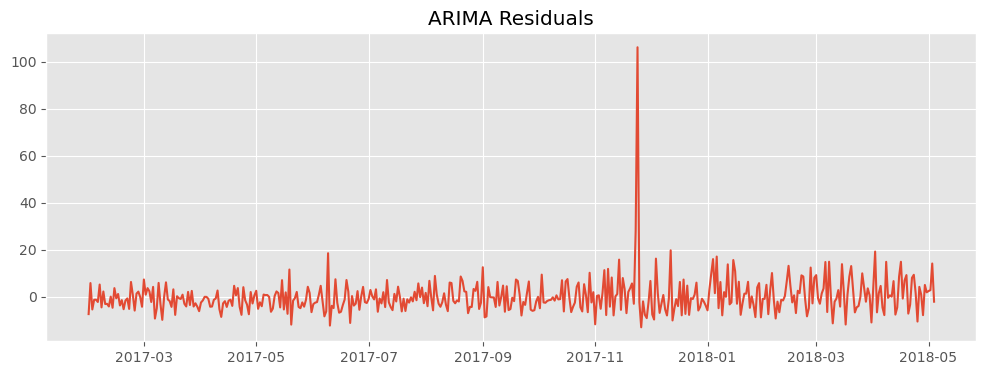

In [400]:
residuals = arima_fit.resid

plt.figure(figsize=(12,4))

plt.plot(residuals)

plt.title("ARIMA Residuals")

plt.show()

PHASE 20 – SARIMA Model

Business Objective
Train a Seasonal ARIMA (SARIMA) model to capture both short-term demand patterns and weekly seasonality,
then evaluate its forecasting performance on the test period.

In [401]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [402]:
sarima_model = SARIMAX(
    train_ts["demand"],
    order=(1,0,1),
    seasonal_order=(1,0,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)

In [403]:
print(sarima_fit.summary())

                                     SARIMAX Results                                     
Dep. Variable:                            demand   No. Observations:                  460
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood               -1558.332
Date:                           Thu, 23 Jul 2026   AIC                           3126.664
Time:                                   00:25:25   BIC                           3147.221
Sample:                               01-30-2017   HQIC                          3134.765
                                    - 05-04-2018                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7269      0.073      9.909      0.000       0.583       0.871
ma.L1         -0.2893      0.108     -2.691

In [404]:
sarima_pred = sarima_fit.forecast(
    steps=len(test_ts)
)

Evaluation
To avoid duplicating code, let's create a reusable function for the classical models.

In [406]:
def evaluate_ts_model(model_name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    actual = np.array(y_true)
    pred = np.array(y_pred)

    mask = actual != 0

    mape = np.mean(
        np.abs((actual[mask] - pred[mask]) / actual[mask])
    ) * 100

    wape = (
        np.sum(np.abs(actual - pred))
        / np.sum(actual)
    ) * 100

    return {
        "Model": model_name,
        "MAE": round(mae,3),
        "RMSE": round(rmse,3),
        "R2": round(r2,3),
        "MAPE": round(mape,2),
        "WAPE": round(wape,2)
    }

In [407]:
sarima_results = evaluate_ts_model(
    "SARIMA",
    test_ts["demand"],
    sarima_pred
)

sarima_results

{'Model': 'SARIMA',
 'MAE': 8.061,
 'RMSE': np.float64(9.911),
 'R2': -0.562,
 'MAPE': np.float64(104.58),
 'WAPE': np.float64(52.62)}

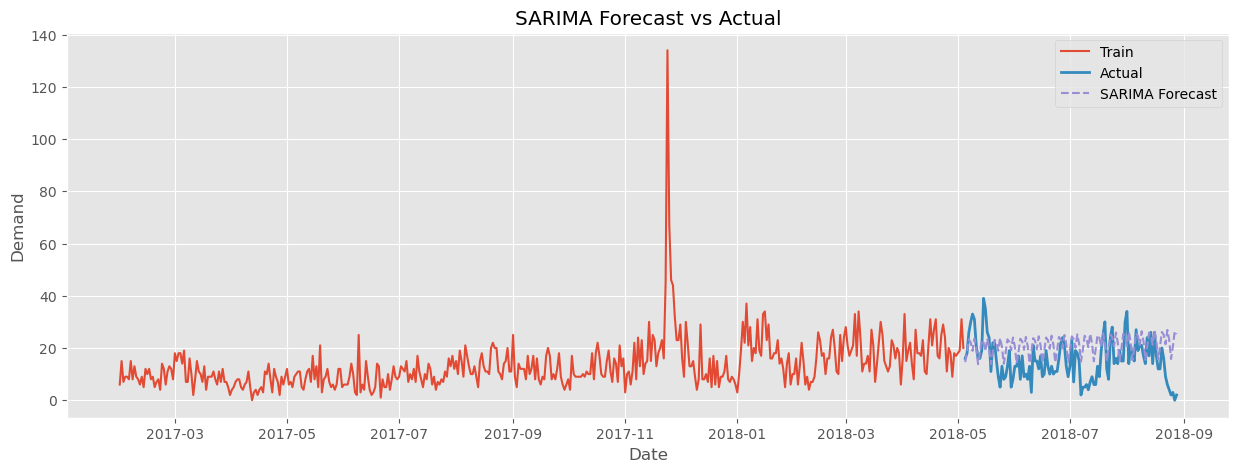

In [408]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    train_ts.index,
    train_ts["demand"],
    label="Train"
)

plt.plot(
    test_ts.index,
    test_ts["demand"],
    label="Actual",
    linewidth=2
)

plt.plot(
    test_ts.index,
    sarima_pred,
    label="SARIMA Forecast",
    linestyle="--"
)

plt.title("SARIMA Forecast vs Actual")

plt.xlabel("Date")
plt.ylabel("Demand")

plt.legend()

plt.show()

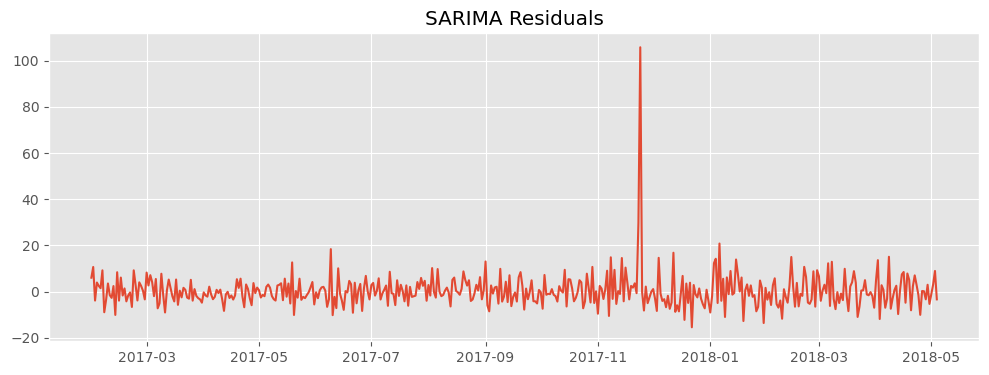

In [409]:
# Residual Analysis



residuals = sarima_fit.resid

plt.figure(figsize=(12,4))

plt.plot(residuals)

plt.title("SARIMA Residuals")

plt.show()

The SARIMA model extends ARIMA by incorporating weekly seasonality. It was trained on the historical demand of
the selected category and evaluated on a held-out test period. Performance metrics and forecast plots were
used to assess whether modeling seasonality improved forecasting accuracy compared with the non-seasonal ARIMA model.

# PHASE 21 – Prophet Forecasting

Business Objective
Train a Prophet model to forecast daily demand by automatically modeling trend and seasonality,
then compare its performance with ARIMA and SARIMA.

In [420]:
pip install prophet

Note: you may need to restart the kernel to use updated packages.


In [421]:
from prophet import Prophet

In [424]:
prophet_df = ts_data.reset_index()

prophet_df = prophet_df.rename(
    columns={
        "date":"ds",
        "demand":"y"
    }
)

prophet_df.head()

,ds,y
0,2017-01-30,6.00
1,2017-01-31,15.00
2,2017-02-01,7.00
3,2017-02-02,9.00
4,2017-02-03,9.00


In [425]:
split = int(len(prophet_df) * 0.80)

train_prophet = prophet_df.iloc[:split]

test_prophet = prophet_df.iloc[split:]

In [426]:
split = int(len(prophet_df) * 0.80)

train_prophet = prophet_df.iloc[:split]

test_prophet = prophet_df.iloc[split:]

In [427]:
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

prophet_model.fit(train_prophet)

00:29:11 - cmdstanpy - INFO - Chain [1] start processing
00:29:11 - cmdstanpy - INFO - Chain [1] done processing


Create Future Dates

In [428]:
future = prophet_model.make_future_dataframe(
    periods=len(test_prophet),
    freq="D"
)

In [429]:
forecast = prophet_model.predict(future)

In [430]:
prophet_pred = forecast["yhat"].iloc[-len(test_prophet):].values

In [431]:
prophet_results = evaluate_ts_model(
    "Prophet",
    test_prophet["y"],
    prophet_pred
)

prophet_results

{'Model': 'Prophet',
 'MAE': 7.765,
 'RMSE': np.float64(9.624),
 'R2': -0.473,
 'MAPE': np.float64(103.61),
 'WAPE': np.float64(50.69)}

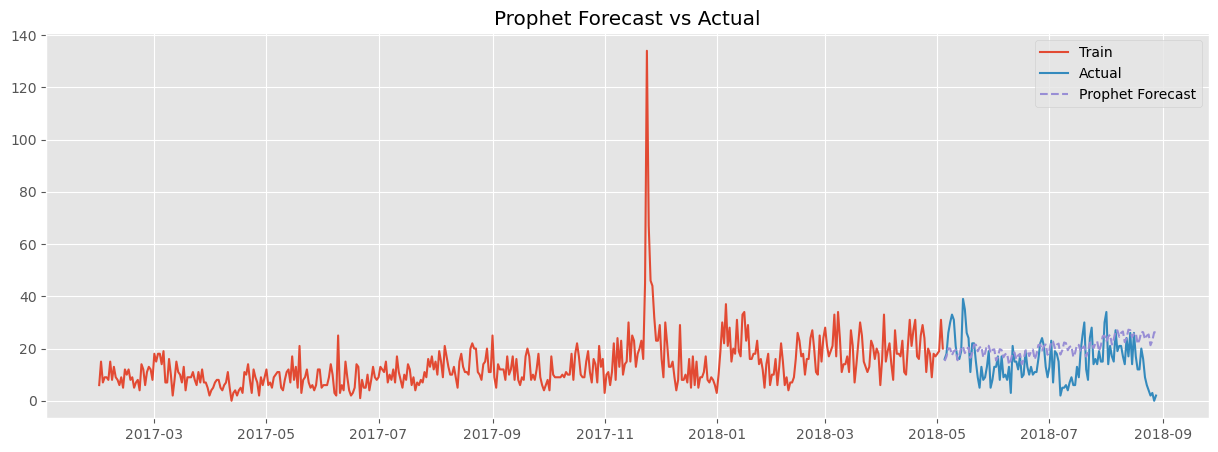

In [432]:
plt.figure(figsize=(15,5))

plt.plot(
    train_prophet["ds"],
    train_prophet["y"],
    label="Train"
)

plt.plot(
    test_prophet["ds"],
    test_prophet["y"],
    label="Actual"
)

plt.plot(
    test_prophet["ds"],
    prophet_pred,
    label="Prophet Forecast",
    linestyle="--"
)

plt.title("Prophet Forecast vs Actual")

plt.legend()

plt.show()

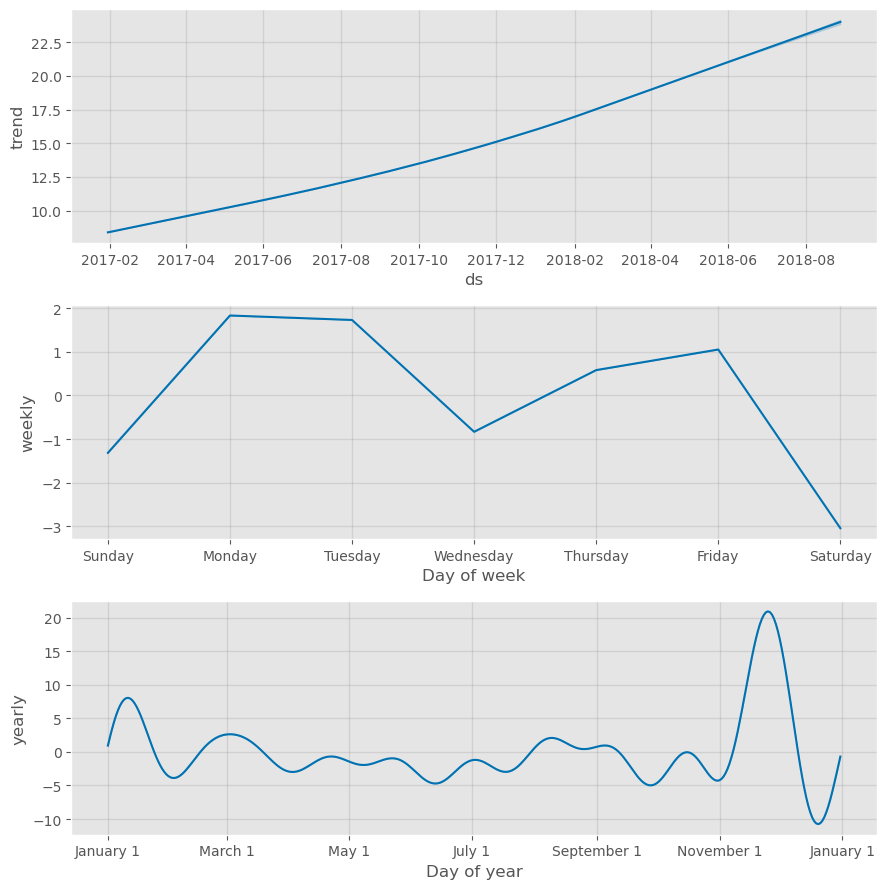

In [433]:
prophet_model.plot_components(
    forecast
)

plt.show()

Prophet was used to model daily demand while automatically capturing trend and weekly/yearly seasonality.
Its forecasts were evaluated on the held-out test period and compared with ARIMA and SARIMA using the
same error metrics to determine the most suitable classical forecasting model.

# PHASE 22 – Classical Model Comparison (ARIMA vs SARIMA vs Prophet)

Business Objective

Compare all classical forecasting models using the same evaluation metrics and select the most suitable model for
single-category demand forecasting.

In [434]:
arima_results = evaluate_ts_model(
    "ARIMA",
    test_ts["demand"],
    arima_pred
)

In [435]:
ts_results = pd.DataFrame([
    arima_results,
    sarima_results,
    prophet_results
])

ts_results

,Model,MAE,RMSE,R2,MAPE,WAPE
0,ARIMA,6.11,7.84,0.02,62.16,39.86
1,SARIMA,8.06,9.91,-0.56,104.58,52.62
2,Prophet,7.76,9.62,-0.47,103.61,50.69


In [436]:
ts_results = ts_results.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

ts_results

,Model,MAE,RMSE,R2,MAPE,WAPE
0,ARIMA,6.11,7.84,0.02,62.16,39.86
1,Prophet,7.76,9.62,-0.47,103.61,50.69
2,SARIMA,8.06,9.91,-0.56,104.58,52.62


# PHASE 23 – Future Demand Forecasting (30-Day Forecast)

In [437]:
print(ts_results)

     Model  MAE  RMSE    R2   MAPE  WAPE
0    ARIMA 6.11  7.84  0.02  62.16 39.86
1  Prophet 7.76  9.62 -0.47 103.61 50.69
2   SARIMA 8.06  9.91 -0.56 104.58 52.62


In [438]:
best_model_name = ts_results.iloc[0]["Model"]

print(best_model_name)

ARIMA


Generate a 30-Day Forecast

In [439]:
future_forecast = sarima_fit.forecast(steps=30)

In [440]:
future_forecast = arima_fit.forecast(steps=30)

In [444]:
future = prophet_model.make_future_dataframe(
    periods=30,
    freq="D"
)

forecast = prophet_model.predict(future)

future_forecast = forecast[["ds", "yhat"]].tail(30)

In [443]:
future_dates = pd.date_range(
    start=ts_data.index.max() + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

future_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast_Demand": future_forecast.values
})

future_df.head()

ValueError: Per-column arrays must each be 1-dimensional

In [445]:
print(best_model_name)

ARIMA


In [446]:
type(future_forecast)

pandas.core.frame.DataFrame

In [447]:
future_forecast.shape

(30, 2)

In [448]:
type(future_forecast)

pandas.core.frame.DataFrame

In [449]:
future_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast_Demand": future_forecast.to_numpy()
})

ValueError: Per-column arrays must each be 1-dimensional

In [450]:
print(best_model_name)

ARIMA


In [451]:
type(future_forecast)

pandas.core.frame.DataFrame

In [452]:
future_forecast.shape

(30, 2)

In [453]:
arima_future_forecast = arima_fit.forecast(steps=30)

In [454]:
future_dates = pd.date_range(
    start=ts_data.index.max() + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

In [455]:
future_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast_Demand": arima_future_forecast.to_numpy()
})

future_df.head()

,Date,Forecast_Demand
0,2018-08-29,19.81
1,2018-08-30,18.74
2,2018-08-31,17.86
3,2018-09-01,17.12
4,2018-09-02,16.50


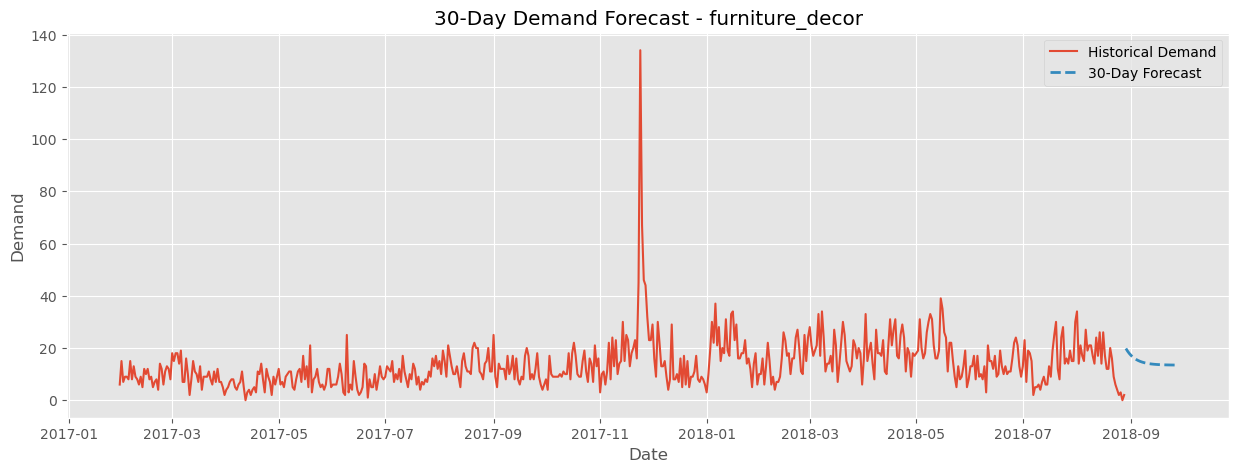

In [456]:
plt.figure(figsize=(15,5))

plt.plot(
    ts_data.index,
    ts_data["demand"],
    label="Historical Demand"
)

plt.plot(
    future_df["Date"],
    future_df["Forecast_Demand"],
    linestyle="--",
    linewidth=2,
    label="30-Day Forecast"
)

plt.title(f"30-Day Demand Forecast - {top_category}")

plt.xlabel("Date")
plt.ylabel("Demand")

plt.legend()

plt.show()

In [457]:
print(ts_results)

     Model  MAE  RMSE    R2   MAPE  WAPE
0    ARIMA 6.11  7.84  0.02  62.16 39.86
1  Prophet 7.76  9.62 -0.47 103.61 50.69
2   SARIMA 8.06  9.91 -0.56 104.58 52.62


In [458]:
best_model_name = ts_results.iloc[0]["Model"]

print("Best Model :", best_model_name)

Best Model : ARIMA


In [459]:
arima_future_forecast = arima_fit.forecast(steps=30)

In [460]:
sarima_future_forecast = sarima_fit.forecast(steps=30)

In [461]:
future = prophet_model.make_future_dataframe(
    periods=30,
    freq="D"
)

forecast = prophet_model.predict(future)

prophet_future_forecast = forecast[["ds", "yhat"]].tail(30)

In [462]:
future_dates = pd.date_range(
    start=ts_data.index.max() + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

future_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast_Demand": arima_future_forecast.to_numpy()
})

future_df.head()

,Date,Forecast_Demand
0,2018-08-29,19.81
1,2018-08-30,18.74
2,2018-08-31,17.86
3,2018-09-01,17.12
4,2018-09-02,16.50


In [463]:
future_dates = pd.date_range(
    start=ts_data.index.max() + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

future_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast_Demand": sarima_future_forecast.to_numpy()
})

future_df.head()

,Date,Forecast_Demand
0,2018-08-29,14.60
1,2018-08-30,18.51
2,2018-08-31,23.22
3,2018-09-01,22.13
4,2018-09-02,18.89


In [464]:
future_df = prophet_future_forecast.rename(
    columns={
        "ds": "Date",
        "yhat": "Forecast_Demand"
    }
)

future_df.head()

,Date,Forecast_Demand
460,2018-05-05,15.25
461,2018-05-06,16.95
462,2018-05-07,20.09
463,2018-05-08,20.00
464,2018-05-09,17.48


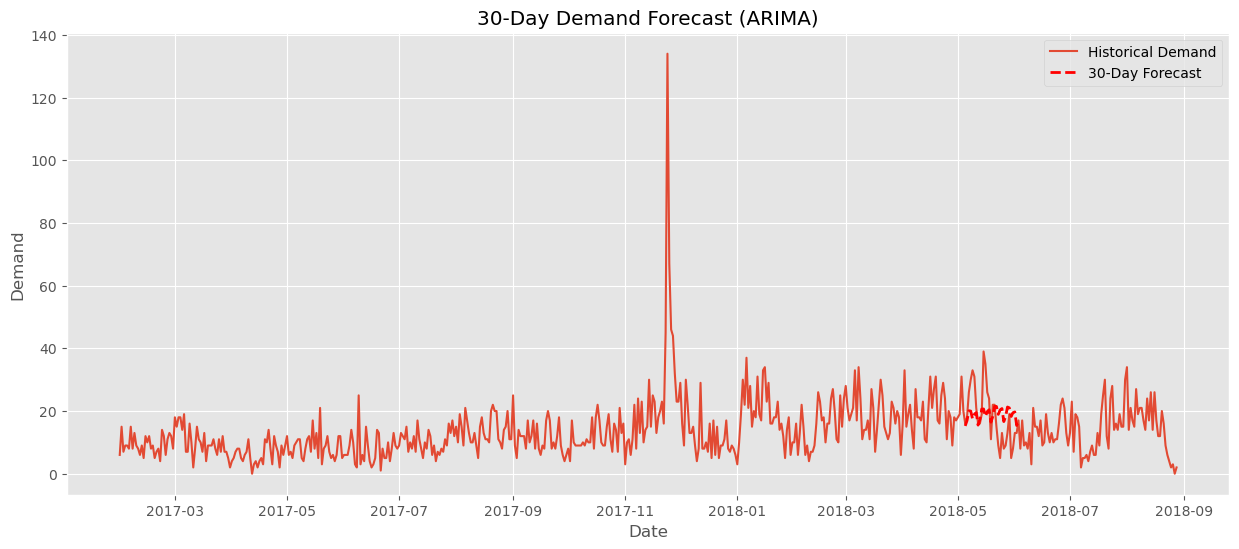

In [465]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(
    ts_data.index,
    ts_data["demand"],
    label="Historical Demand"
)

plt.plot(
    future_df["Date"],
    future_df["Forecast_Demand"],
    color="red",
    linestyle="--",
    linewidth=2,
    label="30-Day Forecast"
)

plt.title(f"30-Day Demand Forecast ({best_model_name})")

plt.xlabel("Date")
plt.ylabel("Demand")

plt.legend()

plt.grid(True)

plt.show()

In [466]:
future_df.to_csv(
    "30_day_demand_forecast.csv",
    index=False
)

print("Forecast saved successfully.")

Forecast saved successfully.


In [467]:
future_df

,Date,Forecast_Demand
460,2018-05-05,15.25
461,2018-05-06,16.95
462,2018-05-07,20.09
463,2018-05-08,20.00
464,2018-05-09,17.48
465,2018-05-10,18.95
466,2018-05-11,19.51
467,2018-05-12,15.51
468,2018-05-13,17.36
469,2018-05-14,20.64


The best-performing classical forecasting model was selected based on RMSE, MAE, R², MAPE, and WAPE.
Using the trained model, demand was forecast for the next 30 days for the selected product category.
These forecasts can support inventory planning, procurement scheduling, stock replenishment,
and operational decision-making. By anticipating future demand, retailers can reduce stockouts,
minimize excess inventory, and improve customer satisfaction.

PHASE 24 – Business Insights, Conclusions, Limitations & Future Scope

Executive Summary

This project developed an end-to-end Retail Demand Forecasting solution using historical e-commerce transaction data.
The workflow included data cleaning, exploratory data analysis, feature engineering, machine learning models,
and classical time series forecasting techniques.

Machine Learning models (Linear Regression, Decision Tree, Random Forest, XGBoost, LightGBM, and CatBoost)
were trained on engineered features across multiple product categories.

Classical forecasting models (ARIMA, SARIMA, and Prophet) were trained on a representative product category to
capture time-dependent demand patterns.

The project demonstrates how predictive analytics can support inventory optimization, demand planning,
and data-driven retail decision-making.

Key Business Insights (Markdown)

Key Business Insights

• Demand varies significantly across product categories.

• Recent demand history (lag features and rolling averages) is one of the strongest predictors of future demand.

• Calendar-based features such as day of week, month, and weekend indicators improve forecasting performance.

• Ensemble Machine Learning models generally outperform simple regression models due to their ability to learn
complex nonlinear relationships.

• Classical time series models effectively capture trend and seasonal demand patterns for individual product categories.

• Accurate demand forecasting can help retailers optimize inventory levels, reduce stockouts, and minimize excess
inventory costs.

Model Performance Summary (Markdown)

Model Performance Summary

Machine Learning Models Evaluated

- Linear Regression
- Decision Tree
- Random Forest
- XGBoost
- LightGBM
- CatBoost

Best Machine Learning Model:
<Replace with your actual best model>

Classical Time Series Models Evaluated

- ARIMA
- SARIMA
- Prophet

Best Classical Forecasting Model:
<Replace with your actual best model>

Business Recommendations

• Use demand forecasts for inventory replenishment planning.

• Maintain higher inventory levels for products with consistently high demand.

• Monitor seasonal demand fluctuations to optimize procurement.

• Integrate forecasting outputs into supply chain planning.

• Retrain forecasting models periodically using newly available sales data.

• Use category-level forecasts to support warehouse and logistics planning.

Project Limitations

• The dataset covers a limited historical period.

• External factors such as promotions, holidays, weather, and competitor pricing were not included.

• Classical forecasting models were demonstrated for one representative product category rather than every category.

• Hyperparameter tuning was limited to maintain reasonable execution time.

Future Scope

• Perform hyperparameter optimization using GridSearchCV or Optuna.

• Develop separate forecasting models for each product category.

• Incorporate external variables such as holidays, promotions, and economic indicators.

• Deploy the forecasting model as a web application using Streamlit or Flask.

• Automate model retraining with scheduled data updates.

• Compare additional forecasting approaches such as LSTM, Temporal Fusion Transformer (TFT), or N-BEATS.

Conclusion

This project successfully developed an end-to-end Retail Demand Forecasting solution using both Machine Learning and
Classical Time Series forecasting techniques.

A complete data science workflow was followed, including data preprocessing, exploratory analysis, feature engineering,
model development, performance evaluation, and future demand forecasting.

Machine Learning models demonstrated strong predictive performance for multi-category demand forecasting, while ARIMA,
SARIMA, and Prophet provided interpretable forecasting solutions for individual product categories.

The proposed forecasting framework can assist retail organizations in improving inventory management,
reducing operational costs, minimizing stock shortages, and supporting strategic business planning through data-driven demand forecasting.